<a href="https://colab.research.google.com/github/Dhanuvarshini-k/Machine-Learning-Based-Transposable-Element-Classification/blob/main/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install biopython -q

import pandas as pd
import numpy as np

from Bio.Seq import Seq
from collections import Counter
from itertools import product

from google.colab import files

print("Biopython and required packages are ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.3 MB/s eta 0:00:00
Biopython and required packages are ready!


In [ ]:
uploaded = files.upload()

Saving TE_sequences.csv to TE_sequences.csv


In [ ]:
filename = list(uploaded.keys())[0]

print("Uploaded file:")
print(filename)

Uploaded file:
TE_sequences.csv


In [ ]:
df = pd.read_csv(filename)

print("File successfully loaded!")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

File successfully loaded!
Number of rows: 459
Number of columns: 6

Column names:
['File_Name', 'Accession_ID', 'Name', 'Description', 'Sequence_Length', 'Sequence']


In [ ]:
print(df["Sequence"].head())

0    TGTCGTTTTCAGAAGACGACCGCACCATCTGACTGGATGTAACGCC...
1    GGGGTTCTAAGCGGGAATCCCAGAAAATTCCGTCATTCCGTATGAT...
2    TGTCATTTTCAGAAGACGACTGCACCAGTTGATTGGGCGTAATGGC...
3    GGCTAATTTTGCCCAACGCGCCAAAAATGTAAAGTTAGCATTTACA...
4    GGGGCTGTACTAGATTAGCAACAATGCTATACTAGTTTTATGAAGA...
Name: Sequence, dtype: object


In [ ]:
print("Missing sequences:", df["Sequence"].isna().sum())

Missing sequences: 0


In [ ]:
df = df.dropna(subset=["Sequence"]).copy()

df["Sequence"] = (
    df["Sequence"]
    .astype(str)
    .str.upper()
    .str.replace(r"[^ACGT]", "", regex=True)
)

print("Sequences cleaned successfully!")

print("Number of sequences:", len(df))
print("\nFirst sequence:")
print(df["Sequence"].iloc[0][:100])

Sequences cleaned successfully!
Number of sequences: 459

First sequence:
TGTCGTTTTCAGAAGACGACCGCACCATCTGACTGGATGTAACGCCTGGTGTGCATACGGCTCCTGACAGCCCAATATCAGGAGTCGTCTGCACCAATCT


In [ ]:
sequence = df["Sequence"].iloc[0]

print("Sequence length:", len(sequence))
print("First 100 bases:")
print(sequence[:100])

Sequence length: 8447
First 100 bases:
TGTCGTTTTCAGAAGACGACCGCACCATCTGACTGGATGTAACGCCTGGTGTGCATACGGCTCCTGACAGCCCAATATCAGGAGTCGTCTGCACCAATCT


In [ ]:
def calculate_kmers(sequence, k):

    sequence = str(sequence).upper()

    total_kmers = len(sequence) - k + 1

    if total_kmers <= 0:
        return {}

    counts = Counter(
        sequence[i:i+k]
        for i in range(total_kmers)
    )

    return counts

In [ ]:
k = 2

kmer_counts = calculate_kmers(sequence, k)

print("2-mer counts:")
print(kmer_counts)

2-mer counts:
Counter({'GC': 1059, 'CG': 944, 'CC': 704, 'GG': 699, 'TG': 602, 'CA': 601, 'GA': 529, 'AC': 467, 'TC': 453, 'AG': 443, 'CT': 434, 'GT': 401, 'AT': 349, 'AA': 331, 'TT': 300, 'TA': 130})


In [ ]:
def calculate_kmer_frequency(sequence, k):

    sequence = str(sequence).upper()

    total_kmers = len(sequence) - k + 1

    if total_kmers <= 0:
        return {}

    counts = Counter(
        sequence[i:i+k]
        for i in range(total_kmers)
    )

    all_kmers = [
        ''.join(x)
        for x in product("ACGT", repeat=k)
    ]

    frequencies = {}

    for kmer in all_kmers:
        frequencies[kmer] = counts.get(kmer, 0) / total_kmers

    return frequencies

In [ ]:
kmer_frequency = calculate_kmer_frequency(sequence, 2)

print(kmer_frequency)

{'AA': 0.039190149183045225, 'AC': 0.05529244612834478, 'AG': 0.05245086431446839, 'AT': 0.04132133554345252, 'CA': 0.07115794458915463, 'CC': 0.08335306654037414, 'CG': 0.11176888467913805, 'CT': 0.05138527113426474, 'GA': 0.06263319914752545, 'GC': 0.12538479753729576, 'GG': 0.0827610703291499, 'GT': 0.0474780961401847, 'TA': 0.015391901491830453, 'TC': 0.05363485673691688, 'TG': 0.07127634383139948, 'TT': 0.03551977267345489}


In [ ]:
kmer_3 = calculate_kmer_frequency(sequence, 3)

print("Number of 3-mers:", len(kmer_3))

print("\nFirst 20 3-mers:")

for kmer, frequency in list(kmer_3.items())[:20]:
    print(kmer, round(frequency, 6))

Number of 3-mers: 64

First 20 3-mers:
AAA 0.007578
AAC 0.012552
AAG 0.012433
AAT 0.006631
ACA 0.010894
ACC 0.018591
ACG 0.017999
ACT 0.007815
AGA 0.008052
AGC 0.022499
AGG 0.014802
AGT 0.007105
ATA 0.003908
ATC 0.016223
ATG 0.015157
ATT 0.006039
CAA 0.01492
CAC 0.018591
CAG 0.023091
CAT 0.014446


In [ ]:
K_VALUES = [1, 2, 3]

results = []

for index, row in df.iterrows():

    sequence = row["Sequence"]

    result = {
        "File_Name": row["File_Name"],
        "Accession_ID": row["Accession_ID"],
        "Name": row["Name"],
        "Sequence_Length": len(sequence)
    }

    for k in K_VALUES:

        frequencies = calculate_kmer_frequency(sequence, k)

        for kmer, frequency in frequencies.items():

            result[f"k{k}_{kmer}"] = frequency

    results.append(result)

print("K-mer calculation completed!")

K-mer calculation completed!


In [ ]:
kmer_df = pd.DataFrame(results)

print("Rows:", kmer_df.shape[0])
print("Columns:", kmer_df.shape[1])

Rows: 459
Columns: 88


In [ ]:
display(kmer_df.head())

,File_Name,Accession_ID,Name,Sequence_Length,k1_A,k1_C,k1_G,k1_T,k2_AA,k2_AC,...,k3_TCG,k3_TCT,k3_TGA,k3_TGC,k3_TGG,k3_TGT,k3_TTA,k3_TTC,k3_TTG,k3_TTT
0,Tn5053-L40585.1.gb,L40585,Exported,8447,0.188351,0.317628,0.318219,0.175802,0.039190,0.055292,...,0.020249,0.007105,0.015275,0.023919,0.023446,0.008644,0.002131,0.010776,0.013025,0.009591
1,Tn4401a-KT378596.gb,KT378596,Exported,9907,0.197840,0.319875,0.296659,0.185626,0.046840,0.058752,...,0.023423,0.010399,0.015447,0.021504,0.019081,0.008884,0.002524,0.015346,0.012317,0.008178
2,Tn402.6-KT345947.gb,KT345947,Exported,8781,0.204077,0.297005,0.287553,0.211365,0.050911,0.056378,...,0.018111,0.009568,0.015605,0.026085,0.021073,0.010821,0.006834,0.015492,0.016403,0.015036
3,TnAbMCR4.3-CP033872.gb,CP033872,Exported,6504,0.305351,0.203875,0.202645,0.288130,0.103183,0.056128,...,0.011535,0.011689,0.023531,0.016610,0.014765,0.014149,0.024300,0.015995,0.023685,0.032452
4,TnEcpKP37BE-LT598652.1.gb,LT598652,Exported,3481,0.280666,0.193335,0.228383,0.297616,0.091667,0.043966,...,0.010348,0.008623,0.022995,0.023857,0.023283,0.018684,0.024720,0.009198,0.025870,0.037367


In [ ]:
k2_columns = [col for col in kmer_df.columns if col.startswith("k2_")]

print(
    "First TE 2-mer frequency sum:",
    kmer_df.loc[0, k2_columns].sum()
)

First TE 2-mer frequency sum: 0.9999999999999999


In [ ]:
k3_columns = [col for col in kmer_df.columns if col.startswith("k3_")]

print(
    "First TE 3-mer frequency sum:",
    kmer_df.loc[0, k3_columns].sum()
)

First TE 3-mer frequency sum: 0.9999999999999996


In [ ]:
output_file = "TE_kmer_composition.xlsx"

kmer_df.to_excel(output_file, index=False)

print("Excel file created:")
print(output_file)

Excel file created:
TE_kmer_composition.xlsx


In [ ]:
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install biopython scikit-learn openpyxl -q

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer

print("Required packages are ready!")

Required packages are ready!


In [ ]:
df = pd.read_csv("TE_sequences.csv")

print("Number of TE sequences:", len(df))
print(df.columns.tolist())

Number of TE sequences: 459
['File_Name', 'Accession_ID', 'Name', 'Description', 'Sequence_Length', 'Sequence']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving TE_sequences.csv to TE_sequences (1).csv


In [ ]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Number of TE sequences:", len(df))
print(df.columns.tolist())

Number of TE sequences: 459
['File_Name', 'Accession_ID', 'Name', 'Description', 'Sequence_Length', 'Sequence']


In [ ]:
df = df.dropna(subset=["Sequence"]).copy()

df["Sequence"] = (
    df["Sequence"]
    .astype(str)
    .str.upper()
    .str.replace(r"[^ACGT]", "", regex=True)
)

print("Sequences ready:", len(df))

Sequences ready: 459


In [ ]:
def make_kmers(sequence, k):
    return " ".join(
        sequence[i:i+k]
        for i in range(len(sequence) - k + 1)
    )

In [ ]:
test_sequence = df["Sequence"].iloc[0]

print("Original sequence:")
print(test_sequence[:100])

print("\n3-mer representation:")
print(make_kmers(test_sequence[:20], 3))

Original sequence:
TGTCGTTTTCAGAAGACGACCGCACCATCTGACTGGATGTAACGCCTGGTGTGCATACGGCTCCTGACAGCCCAATATCAGGAGTCGTCTGCACCAATCT

3-mer representation:
TGT GTC TCG CGT GTT TTT TTT TTC TCA CAG AGA GAA AAG AGA GAC ACG CGA GAC


In [ ]:
k = 3

df["kmer_sequence"] = df["Sequence"].apply(
    lambda x: make_kmers(x, k)
)

print(df[["Name", "kmer_sequence"]].head())

       Name                                      kmer_sequence
0  Exported  TGT GTC TCG CGT GTT TTT TTT TTC TCA CAG AGA GA...
1  Exported  GGG GGG GGT GTT TTC TCT CTA TAA AAG AGC GCG CG...
2  Exported  TGT GTC TCA CAT ATT TTT TTT TTC TCA CAG AGA GA...
3  Exported  GGC GCT CTA TAA AAT ATT TTT TTT TTG TGC GCC CC...
4  Exported  GGG GGG GGC GCT CTG TGT GTA TAC ACT CTA TAG AG...


In [ ]:
vectorizer = CountVectorizer(
    analyzer="word",
    token_pattern=r"(?u)\b[ACGT]+\b"
)

count_matrix = vectorizer.fit_transform(
    df["kmer_sequence"]
)

print("Count matrix shape:")
print(count_matrix.shape)

ValueError: empty vocabulary; perhaps the documents only contain stop words

In [ ]:
# Check whether k-mer sequences were actually created

print("Number of sequences:", len(df))

print("\nFirst k-mer sequence:")
print(df["kmer_sequence"].iloc[0])

print("\nLength of first k-mer sequence:")
print(len(df["kmer_sequence"].iloc[0]))

Number of sequences: 459

First k-mer sequence:
TGT GTC TCG CGT GTT TTT TTT TTC TCA CAG AGA GAA AAG AGA GAC ACG CGA GAC ACC CCG CGC GCA CAC ACC CCA CAT ATC TCT CTG TGA GAC ACT CTG TGG GGA GAT ATG TGT GTA TAA AAC ACG CGC GCC CCT CTG TGG GGT GTG TGT GTG TGC GCA CAT ATA TAC ACG CGG GGC GCT CTC TCC CCT CTG TGA GAC ACA CAG AGC GCC CCC CCA CAA AAT ATA TAT ATC TCA CAG AGG GGA GAG AGT GTC TCG CGT GTC TCT CTG TGC GCA CAC ACC CCA CAA AAT ATC TCT CTC TCG CGA GAC ACT CTA TAT ATG TGC GCT CTC TCA CAA AAT ATA TAC ACT CTC TCG CGT GTG TGT GTG TGC GCA CAC ACC CCA CAA AAA AAG AGC GCG CGA GAG AGG GGT GTT TTT TTG TGG GGG GGC GCA CAT ATG TGA GAC ACA CAT ATC TCA CAG AGA GAC ACA CAC ACT CTC TCC CCA CAC ACC CCG CGA GAT ATT TTG TGC GCC CCG CGC GCG CGC GCA CAA AAG AGG GGC GCG CGT GTG TGG GGC GCC CCA CAC ACC CCC CCT CTG TGC GCC CCC CCG CGA GAC ACG CGA GAG AGG GGC GCA CAT ATG TGG GGG GGC GCG CGC GCA CAA AAG AGC GCC CCC CCG CGG GGC GCA CAC ACC CCG CGG GGA GAC ACG CGG GGA GAA AAA AAT ATC TCA CAT ATC TCG CGG GGG GGC 

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    lowercase=False,
    token_pattern=r'(?u)\b[A-Za-z]+\b'
)

count_matrix = vectorizer.fit_transform(
    df["kmer_sequence"]
)

print("Count Vectorization completed!")
print("Matrix shape:", count_matrix.shape)

Count Vectorization completed!
Matrix shape: (459, 64)


In [ ]:
kmer_features = vectorizer.get_feature_names_out()

print("Number of k-mer features:", len(kmer_features))

print("\nFirst 20 k-mer features:")
print(kmer_features[:20])

Number of k-mer features: 64

First 20 k-mer features:
['AAA' 'AAC' 'AAG' 'AAT' 'ACA' 'ACC' 'ACG' 'ACT' 'AGA' 'AGC' 'AGG' 'AGT'
 'ATA' 'ATC' 'ATG' 'ATT' 'CAA' 'CAC' 'CAG' 'CAT']


In [ ]:
count_df = pd.DataFrame(
    count_matrix.toarray(),
    columns=kmer_features
)

print("Count matrix created!")
print("Rows:", count_df.shape[0])
print("Columns:", count_df.shape[1])

display(count_df.head())

Count matrix created!
Rows: 459
Columns: 64


,AAA,AAC,AAG,AAT,ACA,ACC,ACG,ACT,AGA,AGC,...,TCG,TCT,TGA,TGC,TGG,TGT,TTA,TTC,TTG,TTT
0,64,106,105,56,92,157,152,66,68,190,...,171,60,129,202,198,73,18,91,110,81
1,111,142,131,80,104,198,180,100,84,220,...,232,103,153,213,189,88,25,152,122,81
2,96,139,132,80,92,156,153,94,83,176,...,159,84,137,229,185,95,60,136,144,132
3,249,127,119,176,121,70,70,104,93,124,...,75,76,153,108,96,92,158,104,154,211
4,106,49,81,83,45,42,29,37,52,63,...,36,30,80,83,81,65,86,32,90,130


In [ ]:
metadata = df[
    [
        "File_Name",
        "Accession_ID",
        "Name",
        "Description",
        "Sequence_Length"
    ]
].reset_index(drop=True)

count_df = pd.concat(
    [metadata, count_df],
    axis=1
)

print("Final Count Vectorization table:")
print("Rows:", count_df.shape[0])
print("Columns:", count_df.shape[1])

display(count_df.head())

Final Count Vectorization table:
Rows: 459
Columns: 69


,File_Name,Accession_ID,Name,Description,Sequence_Length,AAA,AAC,AAG,AAT,ACA,...,TCG,TCT,TGA,TGC,TGG,TGT,TTA,TTC,TTG,TTT
0,Tn5053-L40585.1.gb,L40585,Exported,Xanthomonas sp. W17 mercury resistance transpo...,8447,64,106,105,56,92,...,171,60,129,202,198,73,18,91,110,81
1,Tn4401a-KT378596.gb,KT378596,Exported,Klebsiella pneumoniae strain Kp512 plasmid tra...,9907,111,142,131,80,104,...,232,103,153,213,189,88,25,152,122,81
2,Tn402.6-KT345947.gb,KT345947,Exported,Klebsiella pneumoniae strain 2013050801 plasmi...,8781,96,139,132,80,92,...,159,84,137,229,185,95,60,136,144,132
3,TnAbMCR4.3-CP033872.gb,CP033872,Exported,Acinetobacter baumannii strain MRSN15313 plasm...,6504,249,127,119,176,121,...,75,76,153,108,96,92,158,104,154,211
4,TnEcpKP37BE-LT598652.1.gb,LT598652,Exported,"Escherichia coli plasmid pKP37-BE, strain KP37",3481,106,49,81,83,45,...,36,30,80,83,81,65,86,32,90,130


In [ ]:
kmer_columns = list(kmer_features)

first_te_total = count_df.loc[0, kmer_columns].sum()

sequence_length = count_df.loc[0, "Sequence_Length"]

expected_total = sequence_length - 3 + 1

print("Sequence length:", sequence_length)
print("Expected number of 3-mers:", expected_total)
print("Actual counted 3-mers:", first_te_total)

Sequence length: 8447
Expected number of 3-mers: 8445
Actual counted 3-mers: 8445


In [ ]:
count_totals = count_df[kmer_columns].sum(axis=1)

expected_totals = count_df["Sequence_Length"] - 3 + 1

print("All sequences correctly counted:",
      (count_totals == expected_totals).all())

All sequences correctly counted: False


In [ ]:
# Compare actual cleaned sequence length with the Sequence_Length column

df["Actual_Length"] = df["Sequence"].str.len()

check_df = df[[
    "Sequence_Length",
    "Actual_Length"
]].copy()

check_df["Length_Difference"] = (
    check_df["Actual_Length"] - check_df["Sequence_Length"]
)

print(check_df.head(20))

print("\nNumber of sequences with length mismatch:",
      (check_df["Length_Difference"] != 0).sum())

    Sequence_Length  Actual_Length  Length_Difference
0              8447           8447                  0
1              9907           9907                  0
2              8781           8781                  0
3              6504           6504                  0
4              3481           3481                  0
5              1087           1087                  0
6               844            844                  0
7              3267           3267                  0
8              1686           1686                  0
9              5246           5246                  0
10            18735          18735                  0
11             2680           2680                  0
12            18113          18113                  0
13            21353          21353                  0
14             6042           6042                  0
15             4753           4753                  0
16             7629           7629                  0
17             3864         

In [ ]:
# Show sequences where the lengths do not match

mismatch = check_df[check_df["Length_Difference"] != 0]

print(mismatch.head(20))

     Sequence_Length  Actual_Length  Length_Difference
152             7634           7633                 -1
167             8044           8043                 -1
191             9443           9442                 -1
259             7012           6912               -100


In [ ]:
# Check whether k-mer counts match the ACTUAL cleaned sequence length

actual_lengths = df["Sequence"].str.len()

count_totals = count_df[kmer_columns].sum(axis=1)

expected_totals = actual_lengths - k + 1

comparison = pd.DataFrame({
    "Actual_Sequence_Length": actual_lengths,
    "Expected_3mer_Count": expected_totals,
    "Actual_3mer_Count": count_totals
})

comparison["Correct"] = (
    comparison["Expected_3mer_Count"] == comparison["Actual_3mer_Count"]
)

print(comparison.head(20))

print("\nAll sequences correctly counted:",
      comparison["Correct"].all())

print("Number of incorrect sequences:",
      (~comparison["Correct"]).sum())

    Actual_Sequence_Length  Expected_3mer_Count  Actual_3mer_Count  Correct
0                     8447                 8445               8445     True
1                     9907                 9905               9905     True
2                     8781                 8779               8779     True
3                     6504                 6502               6502     True
4                     3481                 3479               3479     True
5                     1087                 1085               1085     True
6                      844                  842                842     True
7                     3267                 3265               3265     True
8                     1686                 1684               1684     True
9                     5246                 5244               5244     True
10                   18735                18733              18733     True
11                    2680                 2678               2678     True
12          

In [ ]:
print("Count Vectorization matrix shape:", count_matrix.shape)
print("Number of k-mer features:", len(kmer_features))

print("\nFirst 10 k-mers:")
print(kmer_features[:10])

print("\nFeature matrix:")
display(count_df.head())

Count Vectorization matrix shape: (459, 64)
Number of k-mer features: 64

First 10 k-mers:
['AAA' 'AAC' 'AAG' 'AAT' 'ACA' 'ACC' 'ACG' 'ACT' 'AGA' 'AGC']

Feature matrix:


,File_Name,Accession_ID,Name,Description,Sequence_Length,AAA,AAC,AAG,AAT,ACA,...,TCG,TCT,TGA,TGC,TGG,TGT,TTA,TTC,TTG,TTT
0,Tn5053-L40585.1.gb,L40585,Exported,Xanthomonas sp. W17 mercury resistance transpo...,8447,64,106,105,56,92,...,171,60,129,202,198,73,18,91,110,81
1,Tn4401a-KT378596.gb,KT378596,Exported,Klebsiella pneumoniae strain Kp512 plasmid tra...,9907,111,142,131,80,104,...,232,103,153,213,189,88,25,152,122,81
2,Tn402.6-KT345947.gb,KT345947,Exported,Klebsiella pneumoniae strain 2013050801 plasmi...,8781,96,139,132,80,92,...,159,84,137,229,185,95,60,136,144,132
3,TnAbMCR4.3-CP033872.gb,CP033872,Exported,Acinetobacter baumannii strain MRSN15313 plasm...,6504,249,127,119,176,121,...,75,76,153,108,96,92,158,104,154,211
4,TnEcpKP37BE-LT598652.1.gb,LT598652,Exported,"Escherichia coli plasmid pKP37-BE, strain KP37",3481,106,49,81,83,45,...,36,30,80,83,81,65,86,32,90,130


In [ ]:
count_output = "TE_CountVectorization_k3.xlsx"

count_df.to_excel(count_output, index=False)

print("Saved:", count_output)

Saved: TE_CountVectorization_k3.xlsx


In [ ]:
# Save Count Vectorization data as CSV
count_csv = "TE_CountVectorization_k3.csv"

count_df.to_csv(count_csv, index=False)

print("Saved:", count_csv)

Saved: TE_CountVectorization_k3.csv


In [ ]:
from google.colab import files

files.download(count_csv)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

df = pd.read_csv("TE_sequences.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'TE_sequences.csv'

In [ ]:
import pandas as pd

df = pd.read_csv("TE_sequences.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'TE_sequences.csv'

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving TE_sequences.csv to TE_sequences.csv


In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!
Dataset shape: (459, 6)

Columns:
['File_Name', 'Accession_ID', 'Name', 'Description', 'Sequence_Length', 'Sequence']


In [ ]:
display(df.head())

,File_Name,Accession_ID,Name,Description,Sequence_Length,Sequence
0,Tn5053-L40585.1.gb,L40585,Exported,Xanthomonas sp. W17 mercury resistance transpo...,8447,TGTCGTTTTCAGAAGACGACCGCACCATCTGACTGGATGTAACGCC...
1,Tn4401a-KT378596.gb,KT378596,Exported,Klebsiella pneumoniae strain Kp512 plasmid tra...,9907,GGGGTTCTAAGCGGGAATCCCAGAAAATTCCGTCATTCCGTATGAT...
2,Tn402.6-KT345947.gb,KT345947,Exported,Klebsiella pneumoniae strain 2013050801 plasmi...,8781,TGTCATTTTCAGAAGACGACTGCACCAGTTGATTGGGCGTAATGGC...
3,TnAbMCR4.3-CP033872.gb,CP033872,Exported,Acinetobacter baumannii strain MRSN15313 plasm...,6504,GGCTAATTTTGCCCAACGCGCCAAAAATGTAAAGTTAGCATTTACA...
4,TnEcpKP37BE-LT598652.1.gb,LT598652,Exported,"Escherichia coli plasmid pKP37-BE, strain KP37",3481,GGGGCTGTACTAGATTAGCAACAATGCTATACTAGTTTTATGAAGA...


In [ ]:
df = df.dropna(subset=["Sequence"]).copy()

df["Sequence"] = (
    df["Sequence"]
    .astype(str)
    .str.upper()
    .str.replace(r"[^ACGT]", "", regex=True)
)

# Create actual length after cleaning
df["Actual_Length"] = df["Sequence"].str.len()

print("Number of valid sequences:", len(df))
print("First sequence:")
print(df["Sequence"].iloc[0][:100])

Number of valid sequences: 459
First sequence:
TGTCGTTTTCAGAAGACGACCGCACCATCTGACTGGATGTAACGCCTGGTGTGCATACGGCTCCTGACAGCCCAATATCAGGAGTCGTCTGCACCAATCT


In [ ]:
def make_kmers(sequence, k):
    return " ".join(
        sequence[i:i+k]
        for i in range(len(sequence) - k + 1)
    )

k = 3

df["kmer_sequence"] = df["Sequence"].apply(
    lambda x: make_kmers(x, k)
)

print("First sequence converted to 3-mers:")
print(df["kmer_sequence"].iloc[0][:300])

First sequence converted to 3-mers:
TGT GTC TCG CGT GTT TTT TTT TTC TCA CAG AGA GAA AAG AGA GAC ACG CGA GAC ACC CCG CGC GCA CAC ACC CCA CAT ATC TCT CTG TGA GAC ACT CTG TGG GGA GAT ATG TGT GTA TAA AAC ACG CGC GCC CCT CTG TGG GGT GTG TGT GTG TGC GCA CAT ATA TAC ACG CGG GGC GCT CTC TCC CCT CTG TGA GAC ACA CAG AGC GCC CCC CCA CAA AAT ATA 


In [ ]:
vectorizer = CountVectorizer(
    lowercase=False,
    token_pattern=r'(?u)\b[A-Za-z]+\b'
)

count_matrix = vectorizer.fit_transform(df["kmer_sequence"])

print("Count Vectorization completed!")
print("Matrix shape:", count_matrix.shape)

Count Vectorization completed!
Matrix shape: (459, 64)


In [ ]:
kmer_features = vectorizer.get_feature_names_out()

print("Number of k-mer features:", len(kmer_features))
print(kmer_features)

Number of k-mer features: 64
['AAA' 'AAC' 'AAG' 'AAT' 'ACA' 'ACC' 'ACG' 'ACT' 'AGA' 'AGC' 'AGG' 'AGT'
 'ATA' 'ATC' 'ATG' 'ATT' 'CAA' 'CAC' 'CAG' 'CAT' 'CCA' 'CCC' 'CCG' 'CCT'
 'CGA' 'CGC' 'CGG' 'CGT' 'CTA' 'CTC' 'CTG' 'CTT' 'GAA' 'GAC' 'GAG' 'GAT'
 'GCA' 'GCC' 'GCG' 'GCT' 'GGA' 'GGC' 'GGG' 'GGT' 'GTA' 'GTC' 'GTG' 'GTT'
 'TAA' 'TAC' 'TAG' 'TAT' 'TCA' 'TCC' 'TCG' 'TCT' 'TGA' 'TGC' 'TGG' 'TGT'
 'TTA' 'TTC' 'TTG' 'TTT']


In [ ]:
count_df = pd.DataFrame(
    count_matrix.toarray(),
    columns=kmer_features
)

display(count_df.head())

,AAA,AAC,AAG,AAT,ACA,ACC,ACG,ACT,AGA,AGC,...,TCG,TCT,TGA,TGC,TGG,TGT,TTA,TTC,TTG,TTT
0,64,106,105,56,92,157,152,66,68,190,...,171,60,129,202,198,73,18,91,110,81
1,111,142,131,80,104,198,180,100,84,220,...,232,103,153,213,189,88,25,152,122,81
2,96,139,132,80,92,156,153,94,83,176,...,159,84,137,229,185,95,60,136,144,132
3,249,127,119,176,121,70,70,104,93,124,...,75,76,153,108,96,92,158,104,154,211
4,106,49,81,83,45,42,29,37,52,63,...,36,30,80,83,81,65,86,32,90,130


In [ ]:
count_totals = count_df.sum(axis=1)

expected_totals = df["Actual_Length"] - k + 1

print(
    "All sequences correctly counted:",
    (count_totals == expected_totals).all()
)

print(
    "Number of incorrect sequences:",
    (count_totals != expected_totals).sum()
)

All sequences correctly counted: True
Number of incorrect sequences: 0


In [ ]:
metadata_columns = [
    "File_Name",
    "Accession_ID",
    "Name",
    "Description"
]

# Keep only columns that actually exist
metadata_columns = [
    col for col in metadata_columns
    if col in df.columns
]

metadata = df[metadata_columns].reset_index(drop=True)

count_df = pd.concat(
    [metadata, count_df],
    axis=1
)

display(count_df.head())

,File_Name,Accession_ID,Name,Description,AAA,AAC,AAG,AAT,ACA,ACC,...,TCG,TCT,TGA,TGC,TGG,TGT,TTA,TTC,TTG,TTT
0,Tn5053-L40585.1.gb,L40585,Exported,Xanthomonas sp. W17 mercury resistance transpo...,64,106,105,56,92,157,...,171,60,129,202,198,73,18,91,110,81
1,Tn4401a-KT378596.gb,KT378596,Exported,Klebsiella pneumoniae strain Kp512 plasmid tra...,111,142,131,80,104,198,...,232,103,153,213,189,88,25,152,122,81
2,Tn402.6-KT345947.gb,KT345947,Exported,Klebsiella pneumoniae strain 2013050801 plasmi...,96,139,132,80,92,156,...,159,84,137,229,185,95,60,136,144,132
3,TnAbMCR4.3-CP033872.gb,CP033872,Exported,Acinetobacter baumannii strain MRSN15313 plasm...,249,127,119,176,121,70,...,75,76,153,108,96,92,158,104,154,211
4,TnEcpKP37BE-LT598652.1.gb,LT598652,Exported,"Escherichia coli plasmid pKP37-BE, strain KP37",106,49,81,83,45,42,...,36,30,80,83,81,65,86,32,90,130


In [ ]:
count_csv = "TE_CountVectorization_k3.csv"

count_df.to_csv(count_csv, index=False)

print("Saved successfully:", count_csv)

Saved successfully: TE_CountVectorization_k3.csv


In [ ]:
files.download(count_csv)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Original dataset columns:")
print(df.columns.tolist())

print("\nFirst 30 TE names and descriptions:")

display(
    df[["Name", "Description"]].head(30)
)

Original dataset columns:
['File_Name', 'Accession_ID', 'Name', 'Description', 'Sequence_Length', 'Sequence', 'Actual_Length', 'kmer_sequence']

First 30 TE names and descriptions:


,Name,Description
0,Exported,Xanthomonas sp. W17 mercury resistance transpo...
1,Exported,Klebsiella pneumoniae strain Kp512 plasmid tra...
2,Exported,Klebsiella pneumoniae strain 2013050801 plasmi...
3,Exported,Acinetobacter baumannii strain MRSN15313 plasm...
4,Exported,"Escherichia coli plasmid pKP37-BE, strain KP37"
5,Exported,Acinetobacter baumannii strain ML hypothetical...
6,Exported,natural linear DNA
7,TnpAF401-CP01825,Acinetobacter baumannii strain AF-401 plasmid ...
8,Exported,natural linear DNA
9,Exported,Alcaligenes faecalis transposon Tn5393d


In [ ]:
pd.set_option("display.max_colwidth", None)

print("Total descriptions:", df["Description"].notna().sum())

display(
    df[["Accession_ID", "Description"]].head(50)
)

Total descriptions: 459


,Accession_ID,Description
0,L40585,"Xanthomonas sp. W17 mercury resistance transposon Tn5053, complete sequence"
1,KT378596,"Klebsiella pneumoniae strain Kp512 plasmid transposon Tn4401a, complete sequence"
2,KT345947,"Klebsiella pneumoniae strain 2013050801 plasmid p0801-IMP, complete sequence"
3,CP033872,"Acinetobacter baumannii strain MRSN15313 plasmid pAb-MCR4.3, complete sequence"
4,LT598652,"Escherichia coli plasmid pKP37-BE, strain KP37"
5,JN872328,"Acinetobacter baumannii strain ML hypothetical protein gene, complete cds; delta RHS-family protein-like gene, partial sequence; TnpA ISAba125 (tnpAISAba125), NDM-2 (blaNDM-2), and BleMBL (bleMBL) genes, complete cds; delta-phosphoribosylanthranilate isomerase-like (delta-iso) gene, complete sequence; TAT (tat), DVT (dvt), GroES (groES), GroEL (groEL), and TnpA ISCR21 (tnpAISCR21) genes, complete cds; delta-PAC-like (delta-pac) gene, complete sequence; TnpA ISAba125 cp2 (tnpAISAba125cp2) gene, complete cds; delta-RHS family protein-like (delta-rhs) gene, partial sequence; and DsbB (dsbB) and glutamate-cysteine ligase genes, complete cds"
6,.,natural linear DNA
7,CP018255,Acinetobacter baumannii strain AF-401 plasmid pAF-401
8,.,natural linear DNA
9,AJ627643,Alcaligenes faecalis transposon Tn5393d


In [ ]:
import re

# Search for Tn family names such as Tn3, Tn7, Tn402, Tn5393d, etc.
tn_matches = df["Description"].astype(str).str.findall(
    r'\bTn[A-Za-z0-9_-]+\b',
    flags=re.IGNORECASE
)

print("Examples of detected Tn families:")

for i, matches in enumerate(tn_matches):
    if matches:
        print(i, matches)

Examples of detected Tn families:
0 ['Tn5053']
1 ['Tn4401a']
5 ['TnpA', 'tnpAISAba125', 'TnpA', 'tnpAISCR21', 'TnpA', 'tnpAISAba125cp2']
9 ['Tn5393d']
11 ['TnAphI', 'Tn1412']
14 ['Tn5393d']
19 ['Tn402', 'TniC', 'tniC', 'TniQ', 'tniQ', 'TniB', 'tniB', 'TniA', 'tniA']
29 ['Tn554']
31 ['Tn1999']
32 ['Tn5042']
33 ['Tn5403', 'tnpA', 'tnpR']
36 ['Tn6260', 'tnpA', 'tnpB', 'tnpC']
37 ['tnpA', 'tnpB']
39 ['TniB', 'tniB-delta1', 'TniA', 'tniA']
40 ['Tn2555']
45 ['TnpA1', 'tnpA1', 'TnpA2', 'tnpA2', 'tnpA3', 'Tn5501', 'TnpA4', 'tnpR', 'tnpA4']
46 ['Tn4321']
52 ['Tn6188']
54 ['Tn1', 'Tn5036-like']
61 ['Tn6001']
64 ['Tn6133']
67 ['Tn10']
69 ['Tn558']
73 ['Tn6246']
76 ['tnpA']
78 ['Tn6246']
79 ['Tn5075']
82 ['Tn3']
83 ['Tn5046']
85 ['Tn558']
88 ['TnAtcArs', 'tnpR', 'tnpA']
89 ['Tn1696']
91 ['Tn551']
98 ['Tn1696']
100 ['Tn1412']
105 ['Tn5393']
107 ['Tn1000', 'tnpR', 'tnpA']
110 ['Tn5501', 'tnpR', 'Tn5501', 'tnpA']
120 ['Tn5041']
125 ['Tn558']
128 ['Tn3434']
133 ['Tn558']
137 ['Tn5422', 'tnpR', 'tnpA']

In [ ]:
# Search for IS family names such as IS6, IS4, IS3, IS21, etc.
is_matches = df["Description"].astype(str).str.findall(
    r'\bIS[A-Za-z0-9_-]+\b',
    flags=re.IGNORECASE
)

print("Examples of detected IS families:")

for i, matches in enumerate(is_matches):
    if matches:
        print(i, matches)

Examples of detected IS families:
5 ['ISAba125', 'isomerase-like', 'iso', 'ISCR21', 'ISAba125']
16 ['island']
23 ['ISKpn7-KT378596']
27 ['IS1251-KR349520']
37 ['IS6100', 'IS6100']
45 ['IS1071']
67 ['IS10-left', 'IS10-right']
76 ['ISEcp1']
94 ['ISKpn6-KT378596']
101 ['IS1326_IS1353-AF071413']
105 ['IS1133']
114 ['IS50L-U00004']
132 ['IS1251-KR349520']
140 ['IS1353-AF071413']
161 ['isomerizing']
175 ['ISKpn6']
201 ['ISSsu5']
216 ['IS1249', 'IS1249']
235 ['isomerizing']
246 ['ISAba125', 'isomerase-like', 'iso', 'ISCR21', 'ISAba125']
250 ['IS1216E-KR349520']
263 ['IS1246']
264 ['ISGNB1-1']
288 ['ISSsu5']
291 ['IS2020', 'IS2020']
300 ['IS1071']
301 ['ISXc5']
302 ['ISPa12', 'ISPa13']
303 ['IS1249', 'IS1249']
315 ['isolate']
328 ['IS50R-U00004']
334 ['IS1249', 'IS1249']
339 ['isomerizing']
352 ['IS26']
366 ['IS1216E-KR349520']
368 ['IS10-left', 'IS10-right']
371 ['ISGNB1-1']
374 ['IS1207-derived']
391 ['isolate']
405 ['IS176']
422 ['IS629']
431 ['ISAba125', 'isomerase-like', 'iso', 'ISCR21', 

In [ ]:
df["Tn_Family"] = tn_matches.apply(
    lambda x: x[0] if len(x) > 0 else None
)

df["IS_Family"] = is_matches.apply(
    lambda x: x[0] if len(x) > 0 else None
)

print("Sequences with Tn family:", df["Tn_Family"].notna().sum())
print("Sequences with IS family:", df["IS_Family"].notna().sum())

print("\nTn families:")
print(df["Tn_Family"].value_counts(dropna=True))

print("\nIS families:")
print(df["IS_Family"].value_counts(dropna=True))

Sequences with Tn family: 154
Sequences with IS family: 44

Tn families:
Tn_Family
Tn558       8
Tn7-like    6
Tn3         5
Tn5393d     4
Tn554       3
           ..
Tn21        1
Tn5037      1
Tn2000      1
Tn501       1
Tn6112      1
Name: count, Length: 106, dtype: int64

IS families:
IS_Family
ISAba125                  3
isomerizing               3
IS1249                    3
IS1071                    2
IS10-left                 2
IS1251-KR349520           2
ISGNB1-1                  2
IS1216E-KR349520          2
isolate                   2
IS26                      2
ISSsu5                    2
ISKpn7-KT378596           1
IS6100                    1
island                    1
IS1353-AF071413           1
IS50L-U00004              1
IS1133                    1
IS1326_IS1353-AF071413    1
ISEcp1                    1
ISKpn6-KT378596           1
ISKpn6                    1
IS1246                    1
ISXc5                     1
IS2020                    1
ISPa12                    1


In [ ]:
unidentified = df[
    df["Tn_Family"].isna() &
    df["IS_Family"].isna()
]

print("Sequences without detected Tn/IS family:",
      len(unidentified))

display(
    unidentified[
        ["Accession_ID", "Name", "Description"]
    ].head(50)
)

Sequences without detected Tn/IS family: 287


,Accession_ID,Name,Description
2,KT345947,Exported,"Klebsiella pneumoniae strain 2013050801 plasmid p0801-IMP, complete sequence"
3,CP033872,Exported,"Acinetobacter baumannii strain MRSN15313 plasmid pAb-MCR4.3, complete sequence"
4,LT598652,Exported,"Escherichia coli plasmid pKP37-BE, strain KP37"
6,.,Exported,natural linear DNA
7,CP018255,TnpAF401-CP01825,Acinetobacter baumannii strain AF-401 plasmid pAF-401
8,.,Exported,natural linear DNA
10,CP000645,Exported,"Aeromonas salmonicida subsp. salmonicida A449 plasmid 4, complete sequence"
12,CP003149,Exported,"Pseudomonas aeruginosa DK2, complete genome"
13,KU736875,Tn6299-KU736875,Uncultured bacterium IN-10 genomic sequence
15,KX772391,Exported,"Escherichia coli strain EHS30-1 plasmid pEHS30-1, complete sequence"


In [ ]:
import re

# Correct IS-family detection:
# Require IS to be followed by at least one number somewhere in the family name.
# This prevents words such as "isolate", "island", and "isomerizing".

is_pattern = r'\bIS[A-Za-z]*\d+[A-Za-z0-9_.-]*(?:_[A-Za-z0-9.-]+)*'

is_matches_corrected = df["Description"].astype(str).str.findall(
    is_pattern,
    flags=re.IGNORECASE
)

df["IS_Family"] = is_matches_corrected.apply(
    lambda x: x[0] if len(x) > 0 else None
)

print("Corrected IS family count:",
      df["IS_Family"].notna().sum())

print("\nCorrected IS families:")
print(df["IS_Family"].value_counts(dropna=True))

Corrected IS family count: 38

Corrected IS families:
IS_Family
ISAba125                  3
IS1249                    3
IS1251-KR349520.1         2
IS10-left                 2
ISGNB1-1                  2
ISSsu5                    2
IS26                      2
IS1216E-KR349520.1        2
IS1071                    2
IS6100                    1
ISKpn7-KT378596           1
IS50L-U00004.1            1
IS1133                    1
IS1326_IS1353-AF071413    1
ISKpn6-KT378596           1
ISEcp1                    1
IS1353-AF071413           1
IS1246                    1
ISKpn6                    1
IS2020                    1
ISXc5                     1
ISPa12                    1
IS50R-U00004.1            1
IS1207-derived            1
IS176                     1
IS629                     1
ISVs1                     1
Name: count, dtype: int64


In [ ]:
print("Tn family examples:")

display(
    df.loc[
        df["Tn_Family"].notna(),
        ["Accession_ID", "Name", "Description", "Tn_Family"]
    ].head(50)
)

Tn family examples:


,Accession_ID,Name,Description,Tn_Family
0,L40585,Exported,"Xanthomonas sp. W17 mercury resistance transposon Tn5053, complete sequence",Tn5053
1,KT378596,Exported,"Klebsiella pneumoniae strain Kp512 plasmid transposon Tn4401a, complete sequence",Tn4401a
5,JN872328,Exported,"Acinetobacter baumannii strain ML hypothetical protein gene, complete cds; delta RHS-family protein-like gene, partial sequence; TnpA ISAba125 (tnpAISAba125), NDM-2 (blaNDM-2), and BleMBL (bleMBL) genes, complete cds; delta-phosphoribosylanthranilate isomerase-like (delta-iso) gene, complete sequence; TAT (tat), DVT (dvt), GroES (groES), GroEL (groEL), and TnpA ISCR21 (tnpAISCR21) genes, complete cds; delta-PAC-like (delta-pac) gene, complete sequence; TnpA ISAba125 cp2 (tnpAISAba125cp2) gene, complete cds; delta-RHS family protein-like (delta-rhs) gene, partial sequence; and DsbB (dsbB) and glutamate-cysteine ligase genes, complete cds",TnpA
9,AJ627643,Exported,Alcaligenes faecalis transposon Tn5393d,Tn5393d
11,L36547,Exported,TnAphI inserted into Pseudomonas aeruginosa 2293E multiresistance b-lactamase transposon Tn1412,TnAphI
14,AJ627643,Exported,Alcaligenes faecalis transposon Tn5393d. Accession: AJ627643,Tn5393d
19,GQ857074,Exported,"Pseudomonas putida strain LD209 plasmid pDL20 transposon Tn402 family IntI1 (intI1), VIM-2 (blaVIM-2), AacA4 (aacA4), TniC (tniC), TniQ (tniQ), TniB (tniB), and TniA (tniA) genes, complete cds",Tn402
29,X03216,Exported,Staphylococcus aureus transposon Tn554,Tn554
31,HE617182,Tn2696-HE617182,Escherichia coli partial transposon Tn1999.3 variant,Tn1999
32,AJ563380,Tn5042-AJ563380,Pseudomonas fluorescens transposon Tn5042,Tn5042


In [ ]:
print("Total sequences with Tn family:",
      df["Tn_Family"].notna().sum())

Total sequences with Tn family: 154


In [ ]:
integron_mask = df["Description"].astype(str).str.contains(
    "integron",
    case=False,
    na=False
)

print("Sequences containing 'integron':",
      integron_mask.sum())

display(
    df.loc[
        integron_mask,
        ["Accession_ID", "Name", "Description"]
    ].head(30)
)

Sequences containing 'integron': 8


,Accession_ID,Name,Description
39,JF810083,Tn7257-JF810083,"Acinetobacter baumannii strain 65FFC class 1 integron IntI1 (intI1), IMP-5 (blaIMP-5), quartenary ammonium compound resistance (qacEdelta1), dihydropteroate synthase (SulI), and hypothetical protein genes, complete cds; TniB (tniB-delta1) gene, complete cds; and TniA (tniA) and putative transposase genes, partial sequence"
61,EF138817,Exported,"Pseudomonas aeruginosa strain 450 transposon Tn6001 containing In450 integron, complete sequence; and unknown genes"
134,LC331665,Exported,"Pseudomonas fulva KUN1351 integron:class 3 DNA, complete sequence"
196,urn.local...2w-91rbju4,Exported,"Escherichia coli plasmid pMSP071 class I sulI-type integron In60, partial sequence"
206,HQ662557,Exported,"Xanthomonas oryzae pv. oryzae strain YNA12-2 class I integron intI1 gene, complete sequence, aminoglycoside 6'-N-acetyltransferase (aacA3), ADP ribosyltransferase (arr3), aminoglycoside adenylyltransferase (aadA1), putative transposase (tniR), putative transposase (tniQ), and putative transposase (tniB) genes, complete cds, and putative transposase (tniA) gene, partial cds"
352,JX235356,Tn7258-JX235356,"Acinetobacter bereziniae strain 118FFC disrupted insertion sequence IS26, partial sequence; In796 integron, complete sequence; TniB (tniB-delta1) gene, complete cds; and disrupted TniA (tniA) gene, partial sequence"
423,AF071413,Exported,"Assembled sequence of transposon Tn21 containing transposition genes, the integron In2, and the mercury resistance operon"
439,AF205943,Tn2000-AF205943,"Escherichia coli plasmid R751 disrupted traC-2 gene, complete sequence; transposon Tn2000 insertion sequence IS26 IS26 transposase (tnpA) gene, complete cds, In53 integron int gene, complete sequence, and quaternary ammonium compound resistance protein (qacH), aminoglycoside 2'-O-adenylyltransferase (aadB), aminoglycoside 6'-N-acetyltransferase (aacA1b), ORFG (orfG), extended spectrum beta lactamase (blaVEB-1), aminoglycoside 2'-O-adenylyltransferase (aadB), ADP-ribosylating transferase (arr2), chloramphenicol resistance protein (cmlA5), oxacillinase (blaoxa-10), aminoglycoside 3'-(9)-O-adenylyltransferase (aadA1), quaternary ammonium compound resistance protein (qacEdelta1), sulphonamide resistance protein (sulI), and ORF5 (orf5) genes, complete cds, and insertion sequence IS26 IS26 transposase (tnpA) gene, complete cds"


In [ ]:
# Start with unknown
df["Broad_Category"] = "Other Gene Region"

# Integron
df.loc[integron_mask, "Broad_Category"] = "Integron"

# Transposon family detected
df.loc[df["Tn_Family"].notna(), "Broad_Category"] = "Transposon"

# IS family detected
df.loc[df["IS_Family"].notna(), "Broad_Category"] = "IS"

print(df["Broad_Category"].value_counts())

Broad_Category
Other Gene Region    288
Transposon           131
IS                    38
Integron               2
Name: count, dtype: int64


In [ ]:
other_df = df[
    df["Broad_Category"] == "Other Gene Region"
]

print("Other Gene Region sequences:",
      len(other_df))

display(
    other_df[
        ["Accession_ID", "Name", "Description"]
    ].head(100)
)

Other Gene Region sequences: 288


,Accession_ID,Name,Description
2,KT345947,Exported,"Klebsiella pneumoniae strain 2013050801 plasmid p0801-IMP, complete sequence"
3,CP033872,Exported,"Acinetobacter baumannii strain MRSN15313 plasmid pAb-MCR4.3, complete sequence"
4,LT598652,Exported,"Escherichia coli plasmid pKP37-BE, strain KP37"
6,.,Exported,natural linear DNA
7,CP018255,TnpAF401-CP01825,Acinetobacter baumannii strain AF-401 plasmid pAF-401
...,...,...,...
152,BDIH01000107,Exported,"Escherichia coli O26 DNA, contig: 2612-21_contig107, strain: NIID080884, whole genome shotgun sequence"
153,JX469833,Exported,"Uncultured bacterium plasmid pWEC911, complete sequence"
155,CP054343,Exported,Escherichia coli strain SCU-164 chromosome
156,CP017991,Exported,"Enterobacter cloacae complex sp. ECNIH7 plasmid pENT-1ac, complete sequence"


In [ ]:
te_name_mask = df["Name"].astype(str).str.contains(
    r'\b(?:Tn|IS)[A-Za-z0-9_-]*\d',
    case=False,
    na=False,
    regex=True
)

print("Sequences with possible Tn/IS information in Name:",
      te_name_mask.sum())

display(
    df.loc[
        te_name_mask,
        ["Accession_ID", "Name", "Description"]
    ].head(100)
)

Sequences with possible Tn/IS information in Name: 61


,Accession_ID,Name,Description
7,CP018255,TnpAF401-CP01825,Acinetobacter baumannii strain AF-401 plasmid pAF-401
13,KU736875,Tn6299-KU736875,Uncultured bacterium IN-10 genomic sequence
21,.,IS102-J01728,natural linear DNA
28,CP017760,Tn5707-CP017760,Cupriavidus necator strain NH9 plasmid pENH91
31,HE617182,Tn2696-HE617182,Escherichia coli partial transposon Tn1999.3 variant
...,...,...,...
404,Y15510,Tn5706-Y15510,"Pasteurella multocida pPMT1 plasmid DNA for tnp, tetR, tetH, tnp genes"
412,KY270852,Tn6321-KY270852,Enterobacter cloacae strain T5282 plasmid pT5282-mphA
414,MK670979,Tn6666-MK670979,"Proteus mirabilis strain HEDJC8FQ glutamine--fructose-6-phosphate aminotransferase (glmS) gene, complete cds; transposon Tn7-like, complete sequence; and ferric iron ABC transporter ATP-binding protein (fbpC) gene, complete cds"
439,AF205943,Tn2000-AF205943,"Escherichia coli plasmid R751 disrupted traC-2 gene, complete sequence; transposon Tn2000 insertion sequence IS26 IS26 transposase (tnpA) gene, complete cds, In53 integron int gene, complete sequence, and quaternary ammonium compound resistance protein (qacH), aminoglycoside 2'-O-adenylyltransferase (aadB), aminoglycoside 6'-N-acetyltransferase (aacA1b), ORFG (orfG), extended spectrum beta lactamase (blaVEB-1), aminoglycoside 2'-O-adenylyltransferase (aadB), ADP-ribosylating transferase (arr2), chloramphenicol resistance protein (cmlA5), oxacillinase (blaoxa-10), aminoglycoside 3'-(9)-O-adenylyltransferase (aadA1), quaternary ammonium compound resistance protein (qacEdelta1), sulphonamide resistance protein (sulI), and ORF5 (orf5) genes, complete cds, and insertion sequence IS26 IS26 transposase (tnpA) gene, complete cds"


In [ ]:
# Combine Name and Description for annotation detection

df["Annotation_Text"] = (
    df["Name"].fillna("").astype(str) + " " +
    df["Description"].fillna("").astype(str)
)

print(df["Annotation_Text"].head())

0         Exported Xanthomonas sp. W17 mercury resistance transposon Tn5053, complete sequence
1    Exported Klebsiella pneumoniae strain Kp512 plasmid transposon Tn4401a, complete sequence
2        Exported Klebsiella pneumoniae strain 2013050801 plasmid p0801-IMP, complete sequence
3      Exported Acinetobacter baumannii strain MRSN15313 plasmid pAb-MCR4.3, complete sequence
4                                      Exported Escherichia coli plasmid pKP37-BE, strain KP37
Name: Annotation_Text, dtype: object


In [ ]:
# Detect Tn family identifiers from Name + Description

tn_pattern = r'\bTn[A-Za-z0-9]+(?:-[A-Za-z0-9_.]+)?\b'

tn_matches_all = df["Annotation_Text"].str.findall(
    tn_pattern,
    flags=re.IGNORECASE
)

df["Tn_Family"] = tn_matches_all.apply(
    lambda x: x[0] if len(x) > 0 else None
)

print("Sequences with Tn family:",
      df["Tn_Family"].notna().sum())

print("\nTn family distribution:")
print(df["Tn_Family"].value_counts(dropna=True).head(30))

Sequences with Tn family: 180

Tn family distribution:
Tn_Family
Tn558               8
Tn3                 5
Tn5393d             4
tnpA                3
Tn554               3
TnpA                3
Tn6246              3
Tn6025              3
Tn5432              3
Tn1546              3
TnPa40              3
Tn1721              3
Tn1332              3
Tn21                2
Tn2502-U58366       2
Tn6072              2
Tn511               2
Tn7                 2
Tn5045              2
Tn1                 2
Tn10                2
Tn1696              2
Tn559               2
Tn5501-like         2
Tn6299-KU736875     1
TnpAF401-CP01825    1
Tn4401a             1
Tn5053              1
TnAphI              1
Tn6133              1
Name: count, dtype: int64


In [ ]:
# Detect IS family identifiers from Name + Description

is_pattern = r'\bIS[A-Za-z]*\d+[A-Za-z0-9_.-]*(?:_[A-Za-z0-9.-]+)*'

is_matches_all = df["Annotation_Text"].str.findall(
    is_pattern,
    flags=re.IGNORECASE
)

df["IS_Family"] = is_matches_all.apply(
    lambda x: x[0] if len(x) > 0 else None
)

print("Sequences with IS family:",
      df["IS_Family"].notna().sum())

print("\nIS family distribution:")
print(df["IS_Family"].value_counts(dropna=True).head(40))

Sequences with IS family: 48

IS family distribution:
IS_Family
ISAba125                  3
IS1249                    3
IS1251-KR349520.1         2
IS1071                    2
ISSsu5                    2
ISGNB1-1                  2
IS26                      2
IS1216E-KR349520.1        2
IS10-left                 2
IS6100                    1
ISKpn7-KT378596           1
IS102-J01728              1
ISEcp1                    1
IS1326_IS1353-AF071413    1
ISKpn6-KT378596           1
IS1133                    1
IS50L-U00004.1            1
IS1353-AF071413           1
ISCR2-CP117330            1
ISPme1-EF585233           1
ISAba19                   1
ISPa17                    1
ISKpn6                    1
ISPme1_surrogate          1
ISPsp7-KJ920384           1
IS2020                    1
ISXc5                     1
ISPa12                    1
IS1246                    1
ISPa104-ISfinder          1
IS50R-U00004.1            1
ISPpu12-AY128707          1
IS1207-derived            1
ISPrre12-KX8

In [ ]:
# Create Level-1 broad classification

df["Broad_Category"] = "Other Gene Region"

# 1. Transposons
df.loc[
    df["Tn_Family"].notna(),
    "Broad_Category"
] = "Transposon"

# 2. IS elements
df.loc[
    df["Tn_Family"].isna() &
    df["IS_Family"].notna(),
    "Broad_Category"
] = "IS"

# 3. Integrons
df.loc[
    df["Tn_Family"].isna() &
    df["IS_Family"].isna() &
    df["Annotation_Text"].str.contains(
        "integron",
        case=False,
        na=False
    ),
    "Broad_Category"
] = "Integron"

print("LEVEL 1 — Broad Category Distribution")
print("---------------------------------------")
print(df["Broad_Category"].value_counts())

LEVEL 1 — Broad Category Distribution
---------------------------------------
Broad_Category
Other Gene Region    253
Transposon           180
IS                    24
Integron               2
Name: count, dtype: int64


In [ ]:
# Create Level-2 family labels

df["Family"] = "Other"

# Transposon families
df.loc[
    df["Tn_Family"].notna(),
    "Family"
] = df.loc[
    df["Tn_Family"].notna(),
    "Tn_Family"
]

# IS families
df.loc[
    df["Tn_Family"].isna() &
    df["IS_Family"].notna(),
    "Family"
] = df.loc[
    df["Tn_Family"].isna() &
    df["IS_Family"].notna(),
    "IS_Family"
]

# Integrons
integron_only = (
    df["Tn_Family"].isna() &
    df["IS_Family"].isna() &
    df["Annotation_Text"].str.contains(
        "integron",
        case=False,
        na=False
    )
)

df.loc[integron_only, "Family"] = "Integron"

print("LEVEL 2 — Family Distribution")
print("--------------------------------")
print(df["Family"].value_counts())

LEVEL 2 — Family Distribution
--------------------------------
Family
Other               253
Tn558                 8
Tn3                   5
Tn5393d               4
tnpA                  3
                   ... 
Tn2000-AF205943       1
Tn501                 1
ISVs1                 1
Tn6112                1
Tn7706-NZ_JABBPH      1
Name: count, Length: 158, dtype: int64


In [ ]:
display(
    df[
        [
            "Accession_ID",
            "Name",
            "Description",
            "Tn_Family",
            "IS_Family",
            "Broad_Category",
            "Family"
        ]
    ].head(50)
)

,Accession_ID,Name,Description,Tn_Family,IS_Family,Broad_Category,Family
0,L40585,Exported,"Xanthomonas sp. W17 mercury resistance transposon Tn5053, complete sequence",Tn5053,None,Transposon,Tn5053
1,KT378596,Exported,"Klebsiella pneumoniae strain Kp512 plasmid transposon Tn4401a, complete sequence",Tn4401a,None,Transposon,Tn4401a
2,KT345947,Exported,"Klebsiella pneumoniae strain 2013050801 plasmid p0801-IMP, complete sequence",None,None,Other Gene Region,Other
3,CP033872,Exported,"Acinetobacter baumannii strain MRSN15313 plasmid pAb-MCR4.3, complete sequence",None,None,Other Gene Region,Other
4,LT598652,Exported,"Escherichia coli plasmid pKP37-BE, strain KP37",None,None,Other Gene Region,Other
5,JN872328,Exported,"Acinetobacter baumannii strain ML hypothetical protein gene, complete cds; delta RHS-family protein-like gene, partial sequence; TnpA ISAba125 (tnpAISAba125), NDM-2 (blaNDM-2), and BleMBL (bleMBL) genes, complete cds; delta-phosphoribosylanthranilate isomerase-like (delta-iso) gene, complete sequence; TAT (tat), DVT (dvt), GroES (groES), GroEL (groEL), and TnpA ISCR21 (tnpAISCR21) genes, complete cds; delta-PAC-like (delta-pac) gene, complete sequence; TnpA ISAba125 cp2 (tnpAISAba125cp2) gene, complete cds; delta-RHS family protein-like (delta-rhs) gene, partial sequence; and DsbB (dsbB) and glutamate-cysteine ligase genes, complete cds",TnpA,ISAba125,Transposon,TnpA
6,.,Exported,natural linear DNA,None,None,Other Gene Region,Other
7,CP018255,TnpAF401-CP01825,Acinetobacter baumannii strain AF-401 plasmid pAF-401,TnpAF401-CP01825,None,Transposon,TnpAF401-CP01825
8,.,Exported,natural linear DNA,None,None,Other Gene Region,Other
9,AJ627643,Exported,Alcaligenes faecalis transposon Tn5393d,Tn5393d,None,Transposon,Tn5393d


In [ ]:
print(df["Broad_Category"].value_counts())
print(df["Family"].value_counts())

Broad_Category
Other Gene Region    253
Transposon           180
IS                    24
Integron               2
Name: count, dtype: int64
Family
Other               253
Tn558                 8
Tn3                   5
Tn5393d               4
tnpA                  3
                   ... 
Tn2000-AF205943       1
Tn501                 1
ISVs1                 1
Tn6112                1
Tn7706-NZ_JABBPH      1
Name: count, Length: 158, dtype: int64


In [ ]:
# Correct Tn family detection
# Tn families should start with "Tn" followed by a number

tn_pattern_corrected = r'\bTn\d+[A-Za-z0-9_.-]*\b'

tn_matches_corrected = df["Annotation_Text"].str.findall(
    tn_pattern_corrected,
    flags=re.IGNORECASE
)

df["Tn_Family"] = tn_matches_corrected.apply(
    lambda x: x[0] if len(x) > 0 else None
)

print("Corrected Tn family count:",
      df["Tn_Family"].notna().sum())

print("\nCorrected Tn families:")
print(df["Tn_Family"].value_counts().head(40))

Corrected Tn family count: 156

Corrected Tn families:
Tn_Family
Tn558               8
Tn3                 5
Tn5393d             4
Tn6246              3
Tn6025              3
Tn1332              3
Tn554               3
Tn5432              3
Tn1                 2
Tn5045              2
Tn5501              2
Tn1696              2
Tn10                2
Tn1412              2
Tn1721              2
Tn6072              2
Tn511               2
Tn7                 2
Tn2502-U58366       2
Tn559               2
Tn5501-like         2
Tn2555.3-AY48515    1
Tn5707-CP017760     1
Tn6133              1
Tn4321-U60777       1
Tn6188              1
Tn6001              1
Tn5403              1
Tn6260              1
Tn551               1
Tn5075              1
Tn5041              1
Tn402-U67194.4      1
Tn2503-CP002179     1
Tn3434              1
Tn5422              1
Tn5393              1
Tn1000              1
Tn5046              1
Tn6668-MK670985     1
Name: count, dtype: int64


In [ ]:
# Recreate Level-1 broad category

df["Broad_Category"] = "Other Gene Region"

# Transposon
df.loc[
    df["Tn_Family"].notna(),
    "Broad_Category"
] = "Transposon"

# IS
df.loc[
    df["Tn_Family"].isna() &
    df["IS_Family"].notna(),
    "Broad_Category"
] = "IS"

# Integron
df.loc[
    df["Tn_Family"].isna() &
    df["IS_Family"].isna() &
    df["Annotation_Text"].str.contains(
        "integron",
        case=False,
        na=False
    ),
    "Broad_Category"
] = "Integron"

print("LEVEL 1 — Broad Category")
print(df["Broad_Category"].value_counts())

LEVEL 1 — Broad Category
Broad_Category
Other Gene Region    270
Transposon           156
IS                    30
Integron               3
Name: count, dtype: int64


In [ ]:
# Recreate Level-2 family label

df["Family"] = "Other"

# Transposon families
df.loc[
    df["Tn_Family"].notna(),
    "Family"
] = df.loc[
    df["Tn_Family"].notna(),
    "Tn_Family"
]

# IS families
is_only = (
    df["Tn_Family"].isna() &
    df["IS_Family"].notna()
)

df.loc[is_only, "Family"] = df.loc[
    is_only,
    "IS_Family"
]

# Integron
integron_only = (
    df["Tn_Family"].isna() &
    df["IS_Family"].isna() &
    df["Annotation_Text"].str.contains(
        "integron",
        case=False,
        na=False
    )
)

df.loc[integron_only, "Family"] = "Integron"

print("LEVEL 2 — Family Distribution")
print(df["Family"].value_counts().head(50))

LEVEL 2 — Family Distribution
Family
Other                     270
Tn558                       8
Tn3                         5
Tn5393d                     4
ISAba125                    3
Tn554                       3
Integron                    3
Tn6246                      3
Tn5432                      3
Tn6025                      3
Tn1332                      3
Tn10                        2
IS1251-KR349520.1           2
Tn1412                      2
ISSsu5                      2
Tn5045                      2
Tn559                       2
Tn1721                      2
Tn2502-U58366               2
Tn5501-like                 2
Tn7                         2
Tn511                       2
Tn6072                      2
Tn1                         2
Tn5501                      2
IS1216E-KR349520.1          2
Tn1696                      2
Tn6299-KU736875             1
Tn5053                      1
Tn4401a                     1
Tn402                       1
Tn5707-CP017760             1
IS1

In [ ]:
print("Number of unique Level-2 families:",
      df["Family"].nunique())

print("\nFamilies excluding Other:")
print(
    df.loc[df["Family"] != "Other", "Family"]
      .value_counts()
)

Number of unique Level-2 families: 146

Families excluding Other:
Family
Tn558                    8
Tn3                      5
Tn5393d                  4
Tn554                    3
ISAba125                 3
                        ..
Tn501                    1
ISVs1                    1
Tn1546.1_p-KR349520.1    1
Tn6112                   1
Tn7706-NZ_JABBPH         1
Name: count, Length: 145, dtype: int64


In [ ]:
family_counts = df["Family"].value_counts()

print("Family distribution:")
display(
    family_counts.to_frame("Number_of_Sequences")
)

Family distribution:


,Number_of_Sequences
Family,
Other,270
Tn558,8
Tn3,5
Tn5393d,4
ISAba125,3
...,...
Tn501,1
ISVs1,1
Tn1546.1_p-KR349520.1,1


In [ ]:
print("Families with at least 2 sequences:",
      (family_counts >= 2).sum())

print("Families with at least 3 sequences:",
      (family_counts >= 3).sum())

print("Families with at least 5 sequences:",
      (family_counts >= 5).sum())

print("Families with only 1 sequence:",
      (family_counts == 1).sum())

Families with at least 2 sequences: 27
Families with at least 3 sequences: 11
Families with at least 5 sequences: 3
Families with only 1 sequence: 119


In [ ]:
labelled_output = "TE_TwoLevel_Classification_Labels.csv"

df.to_csv(
    labelled_output,
    index=False
)

print("Saved:", labelled_output)

Saved: TE_TwoLevel_Classification_Labels.csv


In [ ]:
files.download(labelled_output)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Count Vectorization features
X = count_df[kmer_features]

# Level-1 target
y = df["Broad_Category"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nLevel-1 class distribution:")
print(y.value_counts())

X shape: (459, 64)
y shape: (459,)

Level-1 class distribution:
Broad_Category
Other Gene Region    270
Transposon           156
IS                    30
Integron               3
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 367
Testing samples: 92


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_level1 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_level1.fit(X_train, y_train)

print("Level-1 Random Forest training completed!")

Level-1 Random Forest training completed!


In [ ]:
y_pred_level1 = rf_level1.predict(X_test)

print("Predictions completed!")

print("\nActual:")
print(y_test.values[:20])

print("\nPredicted:")
print(y_pred_level1[:20])

Predictions completed!

Actual:
['Transposon' 'Other Gene Region' 'Other Gene Region' 'Other Gene Region'
 'Other Gene Region' 'Transposon' 'Other Gene Region' 'Transposon'
 'Transposon' 'Other Gene Region' 'Transposon' 'Transposon' 'Transposon'
 'Transposon' 'IS' 'Transposon' 'Transposon' 'Other Gene Region'
 'Other Gene Region' 'Transposon']

Predicted:
['Transposon' 'Transposon' 'Other Gene Region' 'Other Gene Region'
 'Other Gene Region' 'Transposon' 'Transposon' 'Other Gene Region'
 'Other Gene Region' 'Transposon' 'Other Gene Region' 'Other Gene Region'
 'Transposon' 'Transposon' 'Other Gene Region' 'Transposon'
 'Other Gene Region' 'Transposon' 'Transposon' 'Other Gene Region']


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy_level1 = accuracy_score(
    y_test,
    y_pred_level1
)

print("Level-1 Accuracy:", round(accuracy_level1 * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_level1,
        zero_division=0
    )
)

Level-1 Accuracy: 53.26 %

Classification Report:
                   precision    recall  f1-score   support

               IS       0.00      0.00      0.00         6
         Integron       0.00      0.00      0.00         1
Other Gene Region       0.60      0.70      0.65        54
       Transposon       0.39      0.35      0.37        31

         accuracy                           0.53        92
        macro avg       0.25      0.26      0.26        92
     weighted avg       0.49      0.53      0.51        92



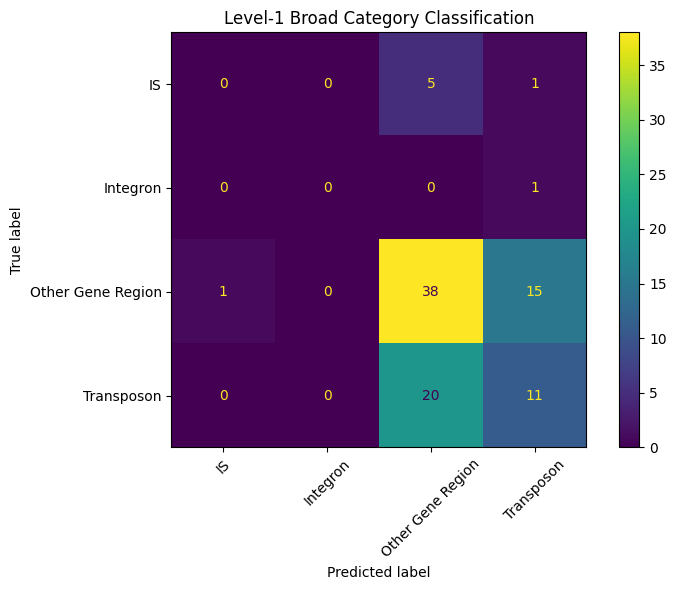

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred_level1,
    labels=rf_level1.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_level1.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("Level-1 Broad Category Classification")
plt.tight_layout()
plt.show()

In [ ]:
print("Level-1 class distribution:")
print(df["Broad_Category"].value_counts())

Level-1 class distribution:
Broad_Category
Other Gene Region    270
Transposon           156
IS                    30
Integron               3
Name: count, dtype: int64


In [ ]:
print("Level-1 class distribution:")
print(df["Broad_Category"].value_counts())

Level-1 class distribution:
Broad_Category
Other Gene Region    270
Transposon           156
IS                    30
Integron               3
Name: count, dtype: int64


In [ ]:
# Step 42: Create binary Level-1 classification labels

df["Level1_Label"] = df["Broad_Category"].apply(
    lambda x: "Transposon" if x == "Transposon" else "Other"
)

print("Level-1 class distribution:")
print(df["Level1_Label"].value_counts())

Level-1 class distribution:
Level1_Label
Other         303
Transposon    156
Name: count, dtype: int64


In [ ]:
print("\nTotal sequences:", len(df))
print("\nClass distribution:")
print(df["Level1_Label"].value_counts())

print("\nCross-check:")
print(pd.crosstab(df["Broad_Category"], df["Level1_Label"]))


Total sequences: 459

Class distribution:
Level1_Label
Other         303
Transposon    156
Name: count, dtype: int64

Cross-check:
Level1_Label       Other  Transposon
Broad_Category                      
IS                    30           0
Integron               3           0
Other Gene Region    270           0
Transposon             0         156


In [ ]:
# Step 43: Prepare Level-1 feature matrix and labels

X_level1 = count_df.loc[df.index, kmer_features]
y_level1 = df["Level1_Label"]

print("Feature matrix shape:", X_level1.shape)
print("Label shape:", y_level1.shape)

print("\nClass distribution:")
print(y_level1.value_counts())

Feature matrix shape: (459, 64)
Label shape: (459,)

Class distribution:
Level1_Label
Other         303
Transposon    156
Name: count, dtype: int64


In [ ]:
# Step 44: Stratified train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_level1,
    y_level1,
    test_size=0.20,
    random_state=42,
    stratify=y_level1
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set shape: (367, 64)
Testing set shape: (92, 64)

Training class distribution:
Level1_Label
Other         242
Transposon    125
Name: count, dtype: int64

Testing class distribution:
Level1_Label
Other         61
Transposon    31
Name: count, dtype: int64


In [ ]:
# Step 45: Train Random Forest for Level-1 classification

from sklearn.ensemble import RandomForestClassifier

rf_level1 = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt"
)

rf_level1.fit(X_train, y_train)

print("Random Forest training completed successfully.")

Random Forest training completed successfully.


In [ ]:
# Step 46: Predict the test set

y_pred = rf_level1.predict(X_test)

print("Prediction completed.")
print("Number of predictions:", len(y_pred))

Prediction completed.
Number of predictions: 92


In [ ]:
# Step 47: Evaluate Level-1 model

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print(f"Level-1 Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Level-1 Accuracy: 65.22%

Classification Report:
              precision    recall  f1-score   support

       Other       0.71      0.80      0.75        61
  Transposon       0.48      0.35      0.41        31

    accuracy                           0.65        92
   macro avg       0.59      0.58      0.58        92
weighted avg       0.63      0.65      0.64        92



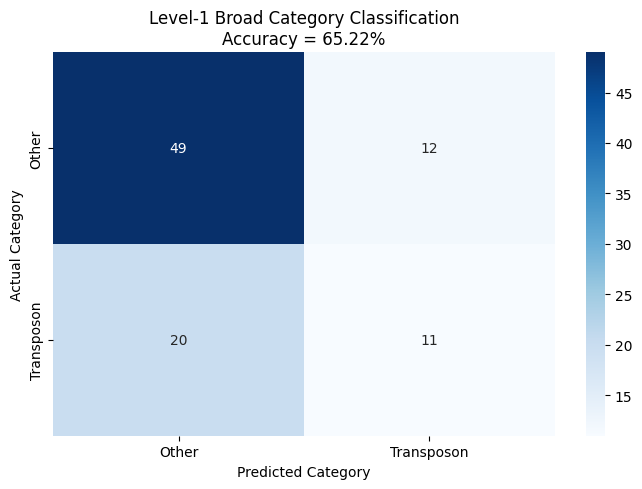

In [ ]:
# Step 48: Confusion Matrix for Level-1 Classification

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Other", "Transposon"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Other", "Transposon"],
    yticklabels=["Other", "Transposon"]
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Level-1 Broad Category Classification\nAccuracy = 65.22%")

plt.tight_layout()
plt.show()

In [ ]:
# Step 48: Train SVM for Level-1 classification

from sklearn.svm import SVC

svm_level1 = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

svm_level1.fit(X_train, y_train)

print("SVM training completed successfully.")

SVM training completed successfully.


In [ ]:
# Step 49: Predict using SVM

y_pred_svm = svm_level1.predict(X_test)

print("SVM prediction completed.")
print("Number of predictions:", len(y_pred_svm))

SVM prediction completed.
Number of predictions: 92


In [ ]:
# Step 50: Evaluate SVM

from sklearn.metrics import accuracy_score, classification_report

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f"SVM Level-1 Accuracy: {accuracy_svm * 100:.2f}%")

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Level-1 Accuracy: 52.17%

SVM Classification Report:
              precision    recall  f1-score   support

       Other       0.71      0.48      0.57        61
  Transposon       0.37      0.61      0.46        31

    accuracy                           0.52        92
   macro avg       0.54      0.54      0.52        92
weighted avg       0.59      0.52      0.53        92



In [ ]:
# Step 51: Create normalized 3-mer frequency features

import numpy as np
import pandas as pd

# Extract only the 64 k-mer count columns
kmer_count_data = count_df[kmer_features].values

# Convert counts to frequencies
kmer_frequency = kmer_count_data / kmer_count_data.sum(axis=1, keepdims=True)

# Create DataFrame
kmer_freq_df = pd.DataFrame(
    kmer_frequency,
    columns=kmer_features,
    index=df.index
)

print("Normalized k-mer feature matrix shape:", kmer_freq_df.shape)

print("\nFirst 5 rows:")
display(kmer_freq_df.head())

Normalized k-mer feature matrix shape: (459, 64)

First 5 rows:


,AAA,AAC,AAG,AAT,ACA,ACC,ACG,ACT,AGA,AGC,...,TCG,TCT,TGA,TGC,TGG,TGT,TTA,TTC,TTG,TTT
0,0.007578,0.012552,0.012433,0.006631,0.010894,0.018591,0.017999,0.007815,0.008052,0.022499,...,0.020249,0.007105,0.015275,0.023919,0.023446,0.008644,0.002131,0.010776,0.013025,0.009591
1,0.011206,0.014336,0.013226,0.008077,0.010500,0.019990,0.018173,0.010096,0.008481,0.022211,...,0.023423,0.010399,0.015447,0.021504,0.019081,0.008884,0.002524,0.015346,0.012317,0.008178
2,0.010935,0.015833,0.015036,0.009113,0.010480,0.017770,0.017428,0.010707,0.009454,0.020048,...,0.018111,0.009568,0.015605,0.026085,0.021073,0.010821,0.006834,0.015492,0.016403,0.015036
3,0.038296,0.019532,0.018302,0.027069,0.018610,0.010766,0.010766,0.015995,0.014303,0.019071,...,0.011535,0.011689,0.023531,0.016610,0.014765,0.014149,0.024300,0.015995,0.023685,0.032452
4,0.030469,0.014085,0.023283,0.023857,0.012935,0.012072,0.008336,0.010635,0.014947,0.018109,...,0.010348,0.008623,0.022995,0.023857,0.023283,0.018684,0.024720,0.009198,0.025870,0.037367


In [ ]:
# Step 52: Train-test split using normalized k-mer frequencies

X_freq = kmer_freq_df.loc[df.index]
y_freq = df["Level1_Label"]

X_train_freq, X_test_freq, y_train_freq, y_test_freq = train_test_split(
    X_freq,
    y_freq,
    test_size=0.20,
    random_state=42,
    stratify=y_freq
)

print("Training set shape:", X_train_freq.shape)
print("Testing set shape:", X_test_freq.shape)

print("\nTraining class distribution:")
print(y_train_freq.value_counts())

print("\nTesting class distribution:")
print(y_test_freq.value_counts())

Training set shape: (367, 64)
Testing set shape: (92, 64)

Training class distribution:
Level1_Label
Other         242
Transposon    125
Name: count, dtype: int64

Testing class distribution:
Level1_Label
Other         61
Transposon    31
Name: count, dtype: int64


In [ ]:
# Step 53: Train SVM using normalized k-mer frequencies

from sklearn.svm import SVC

svm_freq = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

svm_freq.fit(X_train_freq, y_train_freq)

print("Normalized k-mer SVM training completed successfully.")

Normalized k-mer SVM training completed successfully.


In [ ]:
# Step 54: Predict using normalized k-mer SVM

y_pred_svm_freq = svm_freq.predict(X_test_freq)

print("Normalized k-mer SVM prediction completed.")
print("Number of predictions:", len(y_pred_svm_freq))

Normalized k-mer SVM prediction completed.
Number of predictions: 92


In [ ]:
# Step 55: Evaluate normalized k-mer SVM

from sklearn.metrics import accuracy_score, classification_report

accuracy_svm_freq = accuracy_score(
    y_test_freq,
    y_pred_svm_freq
)

print(f"Normalized k-mer SVM Accuracy: {accuracy_svm_freq * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_freq,
        y_pred_svm_freq
    )
)

Normalized k-mer SVM Accuracy: 63.04%

Classification Report:
              precision    recall  f1-score   support

       Other       0.75      0.66      0.70        61
  Transposon       0.46      0.58      0.51        31

    accuracy                           0.63        92
   macro avg       0.61      0.62      0.61        92
weighted avg       0.66      0.63      0.64        92



In [ ]:
# Step 56: Train Logistic Regression using normalized k-mer frequencies

from sklearn.linear_model import LogisticRegression

lr_level1 = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

lr_level1.fit(X_train_freq, y_train_freq)

print("Logistic Regression training completed successfully.")

Logistic Regression training completed successfully.


In [ ]:
# Step 57: Predict using Logistic Regression

y_pred_lr = lr_level1.predict(X_test_freq)

print("Logistic Regression prediction completed.")
print("Number of predictions:", len(y_pred_lr))

Logistic Regression prediction completed.
Number of predictions: 92


In [ ]:
# Step 58: Evaluate Logistic Regression

from sklearn.metrics import accuracy_score, classification_report

accuracy_lr = accuracy_score(y_test_freq, y_pred_lr)

print(f"Logistic Regression Accuracy: {accuracy_lr * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_freq,
        y_pred_lr
    )
)

Logistic Regression Accuracy: 58.70%

Classification Report:
              precision    recall  f1-score   support

       Other       0.73      0.59      0.65        61
  Transposon       0.42      0.58      0.49        31

    accuracy                           0.59        92
   macro avg       0.58      0.59      0.57        92
weighted avg       0.63      0.59      0.60        92



In [ ]:
# Step 60.1: Create 4-mer sequences

k = 4

df["kmer4_sequence"] = df["Sequence"].apply(
    lambda seq: " ".join(
        seq[i:i+k]
        for i in range(len(seq)-k+1)
    )
)

print("4-mer sequences created successfully.")
print(df[["Sequence", "kmer4_sequence"]].head())

4-mer sequences created successfully.
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_4mer = CountVectorizer(
    lowercase=False,
    token_pattern=r'(?u)\b[A-Za-z]+\b'
)

count_matrix_4mer = vectorizer_4mer.fit_transform(
    df["kmer4_sequence"]
)

print("4-mer CountVectorization completed.")
print("Feature matrix shape:", count_matrix_4mer.shape)

4-mer CountVectorization completed.
Feature matrix shape: (459, 256)


In [ ]:
# Step 60.3: Get 4-mer feature names

kmer4_features = vectorizer_4mer.get_feature_names_out()

print("Number of 4-mer features:", len(kmer4_features))
print("First 20 4-mer features:")
print(kmer4_features[:20])

Number of 4-mer features: 256
First 20 4-mer features:
['AAAA' 'AAAC' 'AAAG' 'AAAT' 'AACA' 'AACC' 'AACG' 'AACT' 'AAGA' 'AAGC'
 'AAGG' 'AAGT' 'AATA' 'AATC' 'AATG' 'AATT' 'ACAA' 'ACAC' 'ACAG' 'ACAT']


In [ ]:
# Step 60.4: Convert 4-mer count matrix into DataFrame

count4_df = pd.DataFrame(
    count_matrix_4mer.toarray(),
    columns=kmer4_features,
    index=df.index
)

print("Raw 4-mer count DataFrame created.")
print("Shape:", count4_df.shape)

display(count4_df.head())

Raw 4-mer count DataFrame created.
Shape: (459, 256)


,AAAA,AAAC,AAAG,AAAT,AACA,AACC,AACG,AACT,AAGA,AAGC,...,TTCG,TTCT,TTGA,TTGC,TTGG,TTGT,TTTA,TTTC,TTTG,TTTT
0,15,17,15,17,23,33,33,17,12,46,...,28,11,29,36,28,17,5,22,27,27
1,33,31,23,24,27,37,41,37,27,46,...,53,25,21,48,36,17,4,36,23,18
2,24,30,20,22,27,45,40,27,22,45,...,31,27,27,52,42,23,24,37,32,39
3,97,42,47,63,50,14,35,28,34,39,...,22,20,47,37,43,27,51,38,48,74
4,35,18,32,21,13,13,12,11,24,26,...,9,8,29,21,21,19,42,8,33,47


In [ ]:
# Step 60.5: Add sequence metadata to the 4-mer count table

metadata_4mer = df[
    ["File_Name", "Accession_ID", "Name", "Description"]
].reset_index(drop=True)

count4_df = pd.concat(
    [metadata_4mer, count4_df.reset_index(drop=True)],
    axis=1
)

print("Metadata added successfully.")
print("Final 4-mer count table shape:", count4_df.shape)

display(count4_df.head())

Metadata added successfully.
Final 4-mer count table shape: (459, 260)


,File_Name,Accession_ID,Name,Description,AAAA,AAAC,AAAG,AAAT,AACA,AACC,...,TTCG,TTCT,TTGA,TTGC,TTGG,TTGT,TTTA,TTTC,TTTG,TTTT
0,Tn5053-L40585.1.gb,L40585,Exported,"Xanthomonas sp. W17 mercury resistance transposon Tn5053, complete sequence",15,17,15,17,23,33,...,28,11,29,36,28,17,5,22,27,27
1,Tn4401a-KT378596.gb,KT378596,Exported,"Klebsiella pneumoniae strain Kp512 plasmid transposon Tn4401a, complete sequence",33,31,23,24,27,37,...,53,25,21,48,36,17,4,36,23,18
2,Tn402.6-KT345947.gb,KT345947,Exported,"Klebsiella pneumoniae strain 2013050801 plasmid p0801-IMP, complete sequence",24,30,20,22,27,45,...,31,27,27,52,42,23,24,37,32,39
3,TnAbMCR4.3-CP033872.gb,CP033872,Exported,"Acinetobacter baumannii strain MRSN15313 plasmid pAb-MCR4.3, complete sequence",97,42,47,63,50,14,...,22,20,47,37,43,27,51,38,48,74
4,TnEcpKP37BE-LT598652.1.gb,LT598652,Exported,"Escherichia coli plasmid pKP37-BE, strain KP37",35,18,32,21,13,13,...,9,8,29,21,21,19,42,8,33,47


In [ ]:
# Step 60.6: Verify raw 4-mer counts

# Calculate total 4-mer counts for each sequence
total_4mer_counts = count4_df[kmer4_features].sum(axis=1)

# Expected number of 4-mers = sequence length - 4 + 1
expected_4mer_counts = df["Sequence"].str.len() - 4 + 1

# Check whether both values match
check_4mer = total_4mer_counts.values == expected_4mer_counts.values

print("Total sequences checked:", len(check_4mer))
print("Correct sequences:", check_4mer.sum())
print("Incorrect sequences:", (~check_4mer).sum())

if check_4mer.all():
    print("✅ 4-mer count verification PASSED.")
else:
    print("⚠️ Some sequences have mismatched 4-mer counts.")

Total sequences checked: 459
Correct sequences: 459
Incorrect sequences: 0
✅ 4-mer count verification PASSED.


In [ ]:
# Step 60.7: Prepare raw 4-mer features for Level-1 classification

X_4mer = count4_df[kmer4_features]
y_4mer = df["Level1_Label"]

print("Feature matrix shape:", X_4mer.shape)
print("\nClass distribution:")
print(y_4mer.value_counts())

Feature matrix shape: (459, 256)

Class distribution:
Level1_Label
Other         303
Transposon    156
Name: count, dtype: int64


In [ ]:
# Step 60.8: Train-Test Split for raw 4-mer features

from sklearn.model_selection import train_test_split

X_train_4mer, X_test_4mer, y_train_4mer, y_test_4mer = train_test_split(
    X_4mer,
    y_4mer,
    test_size=0.20,
    random_state=42,
    stratify=y_4mer
)

print("Training set shape:", X_train_4mer.shape)
print("Testing set shape:", X_test_4mer.shape)

print("\nTraining class distribution:")
print(y_train_4mer.value_counts())

print("\nTesting class distribution:")
print(y_test_4mer.value_counts())

Training set shape: (367, 256)
Testing set shape: (92, 256)

Training class distribution:
Level1_Label
Other         242
Transposon    125
Name: count, dtype: int64

Testing class distribution:
Level1_Label
Other         61
Transposon    31
Name: count, dtype: int64


In [ ]:
# Step 60.9: SVM classification using raw 4-mer counts

from sklearn.svm import SVC

svm_4mer = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

svm_4mer.fit(X_train_4mer, y_train_4mer)

y_pred_4mer_svm = svm_4mer.predict(X_test_4mer)

print("Raw 4-mer SVM training completed.")
print("Predictions generated:", len(y_pred_4mer_svm))

Raw 4-mer SVM training completed.
Predictions generated: 92


In [ ]:
# Step 60.10: Evaluate Raw 4-mer SVM

from sklearn.metrics import accuracy_score, classification_report

accuracy_4mer_svm = accuracy_score(
    y_test_4mer,
    y_pred_4mer_svm
)

print(f"Raw 4-mer SVM Accuracy: {accuracy_4mer_svm * 100:.2f}%")
print("\nClassification Report:")
print(
    classification_report(
        y_test_4mer,
        y_pred_4mer_svm,
        labels=["Other", "Transposon"],
        zero_division=0
    )
)

Raw 4-mer SVM Accuracy: 56.52%

Classification Report:
              precision    recall  f1-score   support

       Other       0.73      0.54      0.62        61
  Transposon       0.40      0.61      0.49        31

    accuracy                           0.57        92
   macro avg       0.57      0.58      0.55        92
weighted avg       0.62      0.57      0.58        92



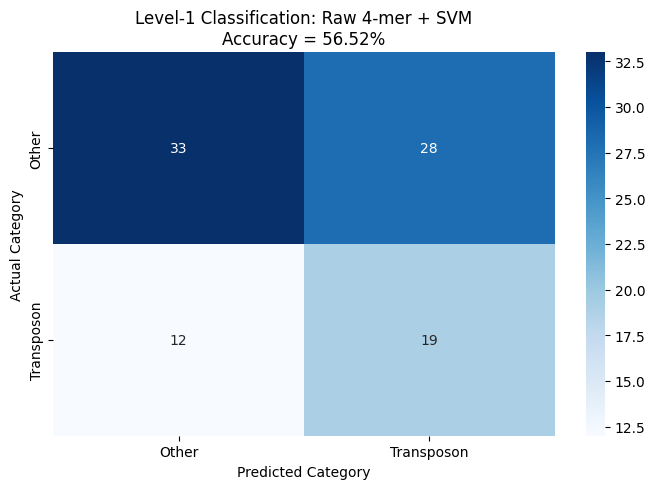

In [ ]:
# Step 60.11: Confusion Matrix - Raw 4-mer + SVM

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_4mer_svm = confusion_matrix(
    y_test_4mer,
    y_pred_4mer_svm,
    labels=["Other", "Transposon"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_4mer_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Other", "Transposon"],
    yticklabels=["Other", "Transposon"]
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Level-1 Classification: Raw 4-mer + SVM\nAccuracy = 56.52%")
plt.tight_layout()
plt.show()

In [ ]:
# Step 60.12: Random Forest using raw 4-mer counts

from sklearn.ensemble import RandomForestClassifier

rf_4mer = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt"
)

rf_4mer.fit(X_train_4mer, y_train_4mer)

y_pred_4mer_rf = rf_4mer.predict(X_test_4mer)

print("Random Forest + raw 4-mer training completed.")
print("Predictions generated:", len(y_pred_4mer_rf))

Random Forest + raw 4-mer training completed.
Predictions generated: 92


In [ ]:
# Step 60.13: Evaluate Random Forest + raw 4-mer counts

from sklearn.metrics import accuracy_score, classification_report

accuracy_4mer_rf = accuracy_score(
    y_test_4mer,
    y_pred_4mer_rf
)

print(f"Random Forest + Raw 4-mer Accuracy: {accuracy_4mer_rf * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_4mer,
        y_pred_4mer_rf,
        labels=["Other", "Transposon"],
        zero_division=0
    )
)

Random Forest + Raw 4-mer Accuracy: 70.65%

Classification Report:
              precision    recall  f1-score   support

       Other       0.75      0.84      0.79        61
  Transposon       0.58      0.45      0.51        31

    accuracy                           0.71        92
   macro avg       0.67      0.64      0.65        92
weighted avg       0.69      0.71      0.70        92



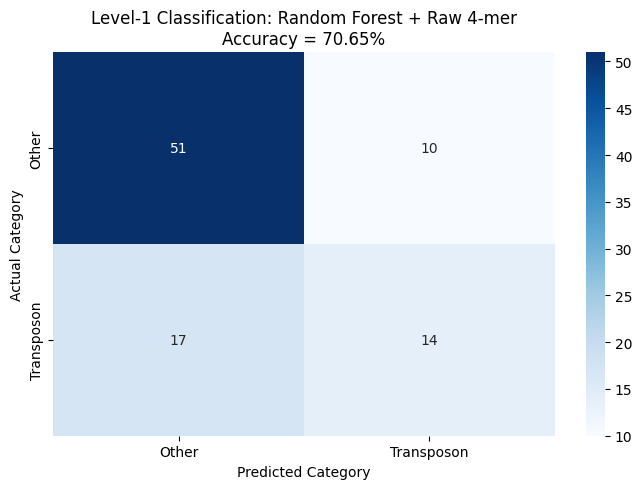

In [ ]:
# Step 60.14: Confusion Matrix - Random Forest + Raw 4-mer

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_4mer_rf = confusion_matrix(
    y_test_4mer,
    y_pred_4mer_rf,
    labels=["Other", "Transposon"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_4mer_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Other", "Transposon"],
    yticklabels=["Other", "Transposon"]
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Level-1 Classification: Random Forest + Raw 4-mer\nAccuracy = 70.65%")

plt.tight_layout()
plt.show()

In [ ]:
# Step 61.1: Create 5-mer sequences

k = 5

df["kmer5_sequence"] = df["Sequence"].apply(
    lambda seq: " ".join(
        seq[i:i+k]
        for i in range(len(seq)-k+1)
    )
)

print("5-mer sequences created successfully.")
print(df[["Sequence", "kmer5_sequence"]].head())

5-mer sequences created successfully.
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [ ]:
# Step 61.2: Raw 5-mer CountVectorization

from sklearn.feature_extraction.text import CountVectorizer

vectorizer_5mer = CountVectorizer(
    lowercase=False,
    token_pattern=r'(?u)\b[A-Za-z]+\b'
)

count_matrix_5mer = vectorizer_5mer.fit_transform(
    df["kmer5_sequence"]
)

print("5-mer CountVectorization completed.")
print("Feature matrix shape:", count_matrix_5mer.shape)

5-mer CountVectorization completed.
Feature matrix shape: (459, 1024)


In [ ]:
# Step 61.3: Get 5-mer feature names

kmer5_features = vectorizer_5mer.get_feature_names_out()

print("Number of 5-mer features:", len(kmer5_features))
print("First 20 5-mer features:")
print(kmer5_features[:20])

Number of 5-mer features: 1024
First 20 5-mer features:
['AAAAA' 'AAAAC' 'AAAAG' 'AAAAT' 'AAACA' 'AAACC' 'AAACG' 'AAACT' 'AAAGA'
 'AAAGC' 'AAAGG' 'AAAGT' 'AAATA' 'AAATC' 'AAATG' 'AAATT' 'AACAA' 'AACAC'
 'AACAG' 'AACAT']


In [ ]:
# Step 61.4: Convert 5-mer count matrix into DataFrame

count5_df = pd.DataFrame(
    count_matrix_5mer.toarray(),
    columns=kmer5_features,
    index=df.index
)

print("Raw 5-mer count DataFrame created.")
print("Shape:", count5_df.shape)

display(count5_df.head())

Raw 5-mer count DataFrame created.
Shape: (459, 1024)


,AAAAA,AAAAC,AAAAG,AAAAT,AAACA,AAACC,AAACG,AAACT,AAAGA,AAAGC,...,TTTCG,TTTCT,TTTGA,TTTGC,TTTGG,TTTGT,TTTTA,TTTTC,TTTTG,TTTTT
0,1,6,3,5,1,10,4,2,3,7,...,6,4,8,5,8,6,2,7,7,11
1,10,6,4,13,5,8,7,11,3,11,...,12,8,4,8,6,5,1,13,2,2
2,7,10,3,4,7,13,5,5,5,8,...,7,9,6,11,6,9,8,10,8,13
3,38,18,16,25,19,2,12,9,11,16,...,10,6,15,12,13,8,17,15,21,21
4,10,5,9,11,4,5,5,4,10,10,...,3,2,7,8,9,9,14,2,13,18


In [ ]:
# Step 61.5: Add metadata to the 5-mer count table

metadata_5mer = df[
    ["File_Name", "Accession_ID", "Name", "Description"]
].reset_index(drop=True)

count5_df = pd.concat(
    [metadata_5mer, count5_df.reset_index(drop=True)],
    axis=1
)

print("Metadata added successfully.")
print("Final 5-mer count table shape:", count5_df.shape)

display(count5_df.head())

Metadata added successfully.
Final 5-mer count table shape: (459, 1028)


,File_Name,Accession_ID,Name,Description,AAAAA,AAAAC,AAAAG,AAAAT,AAACA,AAACC,...,TTTCG,TTTCT,TTTGA,TTTGC,TTTGG,TTTGT,TTTTA,TTTTC,TTTTG,TTTTT
0,Tn5053-L40585.1.gb,L40585,Exported,"Xanthomonas sp. W17 mercury resistance transposon Tn5053, complete sequence",1,6,3,5,1,10,...,6,4,8,5,8,6,2,7,7,11
1,Tn4401a-KT378596.gb,KT378596,Exported,"Klebsiella pneumoniae strain Kp512 plasmid transposon Tn4401a, complete sequence",10,6,4,13,5,8,...,12,8,4,8,6,5,1,13,2,2
2,Tn402.6-KT345947.gb,KT345947,Exported,"Klebsiella pneumoniae strain 2013050801 plasmid p0801-IMP, complete sequence",7,10,3,4,7,13,...,7,9,6,11,6,9,8,10,8,13
3,TnAbMCR4.3-CP033872.gb,CP033872,Exported,"Acinetobacter baumannii strain MRSN15313 plasmid pAb-MCR4.3, complete sequence",38,18,16,25,19,2,...,10,6,15,12,13,8,17,15,21,21
4,TnEcpKP37BE-LT598652.1.gb,LT598652,Exported,"Escherichia coli plasmid pKP37-BE, strain KP37",10,5,9,11,4,5,...,3,2,7,8,9,9,14,2,13,18


In [ ]:
# Step 61.6: Verify raw 5-mer counts

total_5mer_counts = count5_df[kmer5_features].sum(axis=1)

# Expected number of 5-mers = sequence length - 5 + 1
expected_5mer_counts = df["Sequence"].str.len() - 5 + 1

check_5mer = (
    total_5mer_counts.values == expected_5mer_counts.values
)

print("Total sequences checked:", len(check_5mer))
print("Correct sequences:", check_5mer.sum())
print("Incorrect sequences:", (~check_5mer).sum())

if check_5mer.all():
    print("✅ 5-mer count verification PASSED.")
else:
    print("⚠️ Some sequences have mismatched 5-mer counts.")

Total sequences checked: 459
Correct sequences: 459
Incorrect sequences: 0
✅ 5-mer count verification PASSED.


In [ ]:
# Step 61.7: Prepare raw 5-mer features for Level-1 classification

X_5mer = count5_df[kmer5_features]
y_5mer = df["Level1_Label"]

print("Feature matrix shape:", X_5mer.shape)

print("\nClass distribution:")
print(y_5mer.value_counts())

Feature matrix shape: (459, 1024)

Class distribution:
Level1_Label
Other         303
Transposon    156
Name: count, dtype: int64


In [ ]:
# Step 61.8: Train-Test Split for raw 5-mer features

from sklearn.model_selection import train_test_split

X_train_5mer, X_test_5mer, y_train_5mer, y_test_5mer = train_test_split(
    X_5mer,
    y_5mer,
    test_size=0.20,
    random_state=42,
    stratify=y_5mer
)

print("Training set shape:", X_train_5mer.shape)
print("Testing set shape:", X_test_5mer.shape)

print("\nTraining class distribution:")
print(y_train_5mer.value_counts())

print("\nTesting class distribution:")
print(y_test_5mer.value_counts())

Training set shape: (367, 1024)
Testing set shape: (92, 1024)

Training class distribution:
Level1_Label
Other         242
Transposon    125
Name: count, dtype: int64

Testing class distribution:
Level1_Label
Other         61
Transposon    31
Name: count, dtype: int64


In [ ]:
# Step 61.9: Random Forest using raw 5-mer counts

from sklearn.ensemble import RandomForestClassifier

rf_5mer = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt"
)

rf_5mer.fit(X_train_5mer, y_train_5mer)

y_pred_5mer_rf = rf_5mer.predict(X_test_5mer)

print("Random Forest + raw 5-mer training completed.")
print("Predictions generated:", len(y_pred_5mer_rf))

Random Forest + raw 5-mer training completed.
Predictions generated: 92


In [ ]:
# Step 61.10: Evaluate Random Forest + raw 5-mer counts

from sklearn.metrics import accuracy_score, classification_report

accuracy_5mer_rf = accuracy_score(
    y_test_5mer,
    y_pred_5mer_rf
)

print(f"Random Forest + Raw 5-mer Accuracy: {accuracy_5mer_rf * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_5mer,
        y_pred_5mer_rf,
        labels=["Other", "Transposon"],
        zero_division=0
    )
)

Random Forest + Raw 5-mer Accuracy: 77.17%

Classification Report:
              precision    recall  f1-score   support

       Other       0.76      0.95      0.85        61
  Transposon       0.81      0.42      0.55        31

    accuracy                           0.77        92
   macro avg       0.79      0.69      0.70        92
weighted avg       0.78      0.77      0.75        92



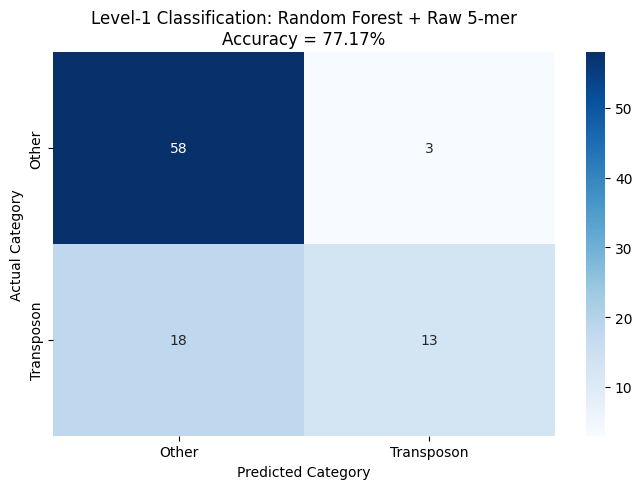

In [ ]:
# Step 61.11: Confusion Matrix - Random Forest + Raw 5-mer

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_5mer_rf = confusion_matrix(
    y_test_5mer,
    y_pred_5mer_rf,
    labels=["Other", "Transposon"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_5mer_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Other", "Transposon"],
    yticklabels=["Other", "Transposon"]
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Level-1 Classification: Random Forest + Raw 5-mer\nAccuracy = 77.17%")

plt.tight_layout()
plt.show()

In [ ]:
# Step 62.1: Create 6-mer sequences

k = 6

df["kmer6_sequence"] = df["Sequence"].apply(
    lambda seq: " ".join(
        seq[i:i+k]
        for i in range(len(seq)-k+1)
    )
)

print("6-mer sequences created successfully.")
print(df[["Sequence", "kmer6_sequence"]].head())

6-mer sequences created successfully.
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [ ]:
# Step 62.2: Raw 6-mer CountVectorization

from sklearn.feature_extraction.text import CountVectorizer

vectorizer_6mer = CountVectorizer(
    lowercase=False,
    token_pattern=r'(?u)\b[A-Za-z]+\b'
)

count_matrix_6mer = vectorizer_6mer.fit_transform(
    df["kmer6_sequence"]
)

print("6-mer CountVectorization completed.")
print("Feature matrix shape:", count_matrix_6mer.shape)

6-mer CountVectorization completed.
Feature matrix shape: (459, 4096)


In [ ]:
# Step 62.3: Get 6-mer feature names

kmer6_features = vectorizer_6mer.get_feature_names_out()

print("Number of 6-mer features:", len(kmer6_features))
print("First 20 6-mer features:")
print(kmer6_features[:20])

Number of 6-mer features: 4096
First 20 6-mer features:
['AAAAAA' 'AAAAAC' 'AAAAAG' 'AAAAAT' 'AAAACA' 'AAAACC' 'AAAACG' 'AAAACT'
 'AAAAGA' 'AAAAGC' 'AAAAGG' 'AAAAGT' 'AAAATA' 'AAAATC' 'AAAATG' 'AAAATT'
 'AAACAA' 'AAACAC' 'AAACAG' 'AAACAT']


In [ ]:
# Step 62.4: Convert 6-mer count matrix into DataFrame

count6_df = pd.DataFrame(
    count_matrix_6mer.toarray(),
    columns=kmer6_features,
    index=df.index
)

print("Raw 6-mer count DataFrame created.")
print("Shape:", count6_df.shape)

display(count6_df.head())

Raw 6-mer count DataFrame created.
Shape: (459, 4096)


,AAAAAA,AAAAAC,AAAAAG,AAAAAT,AAAACA,AAAACC,AAAACG,AAAACT,AAAAGA,AAAAGC,...,TTTTCG,TTTTCT,TTTTGA,TTTTGC,TTTTGG,TTTTGT,TTTTTA,TTTTTC,TTTTTG,TTTTTT
0,0,0,0,1,1,4,1,0,1,2,...,2,1,3,0,2,2,2,1,4,4
1,1,2,0,7,0,2,1,3,0,3,...,3,4,1,1,0,0,0,1,1,0
2,3,3,0,1,4,1,2,3,0,2,...,0,3,2,3,1,2,4,2,4,3
3,12,4,7,15,9,1,6,2,3,4,...,3,3,8,7,5,1,5,5,7,4
4,3,1,6,0,0,0,3,2,1,5,...,0,0,2,3,4,4,3,0,6,9


In [ ]:
# Step 62.5: Add metadata to the 6-mer count table

metadata_6mer = df[
    ["File_Name", "Accession_ID", "Name", "Description"]
].reset_index(drop=True)

count6_df = pd.concat(
    [metadata_6mer, count6_df.reset_index(drop=True)],
    axis=1
)

print("Metadata added successfully.")
print("Final 6-mer count table shape:", count6_df.shape)

display(count6_df.head())

Metadata added successfully.
Final 6-mer count table shape: (459, 4100)


,File_Name,Accession_ID,Name,Description,AAAAAA,AAAAAC,AAAAAG,AAAAAT,AAAACA,AAAACC,...,TTTTCG,TTTTCT,TTTTGA,TTTTGC,TTTTGG,TTTTGT,TTTTTA,TTTTTC,TTTTTG,TTTTTT
0,Tn5053-L40585.1.gb,L40585,Exported,"Xanthomonas sp. W17 mercury resistance transposon Tn5053, complete sequence",0,0,0,1,1,4,...,2,1,3,0,2,2,2,1,4,4
1,Tn4401a-KT378596.gb,KT378596,Exported,"Klebsiella pneumoniae strain Kp512 plasmid transposon Tn4401a, complete sequence",1,2,0,7,0,2,...,3,4,1,1,0,0,0,1,1,0
2,Tn402.6-KT345947.gb,KT345947,Exported,"Klebsiella pneumoniae strain 2013050801 plasmid p0801-IMP, complete sequence",3,3,0,1,4,1,...,0,3,2,3,1,2,4,2,4,3
3,TnAbMCR4.3-CP033872.gb,CP033872,Exported,"Acinetobacter baumannii strain MRSN15313 plasmid pAb-MCR4.3, complete sequence",12,4,7,15,9,1,...,3,3,8,7,5,1,5,5,7,4
4,TnEcpKP37BE-LT598652.1.gb,LT598652,Exported,"Escherichia coli plasmid pKP37-BE, strain KP37",3,1,6,0,0,0,...,0,0,2,3,4,4,3,0,6,9


In [ ]:
# Step 62.6: Verify raw 6-mer counts

total_6mer_counts = count6_df[kmer6_features].sum(axis=1)

# Expected number of 6-mers = sequence length - 6 + 1
expected_6mer_counts = df["Sequence"].str.len() - 6 + 1

check_6mer = (
    total_6mer_counts.values == expected_6mer_counts.values
)

print("Total sequences checked:", len(check_6mer))
print("Correct sequences:", check_6mer.sum())
print("Incorrect sequences:", (~check_6mer).sum())

if check_6mer.all():
    print("✅ 6-mer count verification PASSED.")
else:
    print("⚠️ Some sequences have mismatched 6-mer counts.")

Total sequences checked: 459
Correct sequences: 459
Incorrect sequences: 0
✅ 6-mer count verification PASSED.


In [ ]:
# Step 62.7: Prepare raw 6-mer features for Level-1 classification

X_6mer = count6_df[kmer6_features]
y_6mer = df["Level1_Label"]

print("Feature matrix shape:", X_6mer.shape)

print("\nClass distribution:")
print(y_6mer.value_counts())

Feature matrix shape: (459, 4096)

Class distribution:
Level1_Label
Other         303
Transposon    156
Name: count, dtype: int64


In [ ]:
# Step 62.8A: Train-Test Split for raw 6-mer features

from sklearn.model_selection import train_test_split

X_train_6mer, X_test_6mer, y_train_6mer, y_test_6mer = train_test_split(
    X_6mer,
    y_6mer,
    test_size=0.20,
    random_state=42,
    stratify=y_6mer
)

print("Training set shape:", X_train_6mer.shape)
print("Testing set shape:", X_test_6mer.shape)

Training set shape: (367, 4096)
Testing set shape: (92, 4096)


In [ ]:
# Step 62.8: Random Forest using raw 6-mer counts

from sklearn.ensemble import RandomForestClassifier

rf_6mer = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt"
)

rf_6mer.fit(X_train_6mer, y_train_6mer)

y_pred_6mer_rf = rf_6mer.predict(X_test_6mer)

print("Random Forest + raw 6-mer training completed.")
print("Predictions generated:", len(y_pred_6mer_rf))

Random Forest + raw 6-mer training completed.
Predictions generated: 92


In [ ]:
# Step 62.9: Random Forest using raw 6-mer counts

from sklearn.ensemble import RandomForestClassifier

rf_6mer = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt"
)

rf_6mer.fit(X_train_6mer, y_train_6mer)

y_pred_6mer_rf = rf_6mer.predict(X_test_6mer)

print("Random Forest + raw 6-mer training completed.")
print("Predictions generated:", len(y_pred_6mer_rf))

Random Forest + raw 6-mer training completed.
Predictions generated: 92


In [ ]:
# Step 62.10: Evaluate Random Forest + raw 6-mer counts

from sklearn.metrics import accuracy_score, classification_report

accuracy_6mer_rf = accuracy_score(
    y_test_6mer,
    y_pred_6mer_rf
)

print(f"Random Forest + Raw 6-mer Accuracy: {accuracy_6mer_rf * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_6mer,
        y_pred_6mer_rf,
        labels=["Other", "Transposon"],
        zero_division=0
    )
)

Random Forest + Raw 6-mer Accuracy: 72.83%

Classification Report:
              precision    recall  f1-score   support

       Other       0.74      0.90      0.81        61
  Transposon       0.67      0.39      0.49        31

    accuracy                           0.73        92
   macro avg       0.70      0.64      0.65        92
weighted avg       0.72      0.73      0.71        92



In [ ]:
# Step 61.8A: Train-Test Split for raw 5-mer SVM

from sklearn.model_selection import train_test_split

X_train_5mer, X_test_5mer, y_train_5mer, y_test_5mer = train_test_split(
    X_5mer,
    y_5mer,
    test_size=0.20,
    random_state=42,
    stratify=y_5mer
)

print("Training set shape:", X_train_5mer.shape)
print("Testing set shape:", X_test_5mer.shape)

Training set shape: (367, 1024)
Testing set shape: (92, 1024)


In [ ]:
# Step 61.9: SVM using raw 5-mer counts

from sklearn.svm import SVC

svm_5mer = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

svm_5mer.fit(X_train_5mer, y_train_5mer)

y_pred_5mer_svm = svm_5mer.predict(X_test_5mer)

print("SVM + raw 5-mer training completed.")
print("Predictions generated:", len(y_pred_5mer_svm))


SVM + raw 5-mer training completed.
Predictions generated: 92


In [ ]:
# Step 61.10: Evaluate SVM + raw 5-mer counts

from sklearn.metrics import accuracy_score, classification_report

accuracy_5mer_svm = accuracy_score(
    y_test_5mer,
    y_pred_5mer_svm
)

print(f"SVM + Raw 5-mer Accuracy: {accuracy_5mer_svm * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_5mer,
        y_pred_5mer_svm,
        labels=["Other", "Transposon"],
        zero_division=0
    )
)

SVM + Raw 5-mer Accuracy: 65.22%

Classification Report:
              precision    recall  f1-score   support

       Other       0.77      0.67      0.72        61
  Transposon       0.49      0.61      0.54        31

    accuracy                           0.65        92
   macro avg       0.63      0.64      0.63        92
weighted avg       0.68      0.65      0.66        92



In [ ]:
# Step 62.9: SVM using raw 6-mer counts

from sklearn.svm import SVC

svm_6mer = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

svm_6mer.fit(X_train_6mer, y_train_6mer)

y_pred_6mer_svm = svm_6mer.predict(X_test_6mer)

print("SVM + raw 6-mer training completed.")
print("Predictions generated:", len(y_pred_6mer_svm))

SVM + raw 6-mer training completed.
Predictions generated: 92


In [ ]:
# Step 62.10: Evaluate SVM + raw 6-mer counts

from sklearn.metrics import accuracy_score, classification_report

accuracy_6mer_svm = accuracy_score(
    y_test_6mer,
    y_pred_6mer_svm
)

print(f"SVM + Raw 6-mer Accuracy: {accuracy_6mer_svm * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_6mer,
        y_pred_6mer_svm,
        labels=["Other", "Transposon"],
        zero_division=0
    )
)

SVM + Raw 6-mer Accuracy: 67.39%

Classification Report:
              precision    recall  f1-score   support

       Other       0.78      0.70      0.74        61
  Transposon       0.51      0.61      0.56        31

    accuracy                           0.67        92
   macro avg       0.65      0.66      0.65        92
weighted avg       0.69      0.67      0.68        92



In [ ]:
# Step 63.1: Sequence-level feature engineering

import numpy as np

def calculate_sequence_features(seq):
    length = len(seq)

    if length == 0:
        return pd.Series({
            "Sequence_Length": 0,
            "GC_Content": 0,
            "A_Content": 0,
            "T_Content": 0,
            "G_Content": 0,
            "C_Content": 0
        })

    return pd.Series({
        "Sequence_Length": length,
        "GC_Content": ((seq.count("G") + seq.count("C")) / length) * 100,
        "A_Content": (seq.count("A") / length) * 100,
        "T_Content": (seq.count("T") / length) * 100,
        "G_Content": (seq.count("G") / length) * 100,
        "C_Content": (seq.count("C") / length) * 100
    })

sequence_features = df["Sequence"].apply(calculate_sequence_features)

print("Sequence-level features created successfully.")
print("Feature matrix shape:", sequence_features.shape)

display(sequence_features.head())

Sequence-level features created successfully.
Feature matrix shape: (459, 6)


,Sequence_Length,GC_Content,A_Content,T_Content,G_Content,C_Content
0,8447.0,63.584705,18.835089,17.580206,31.821949,31.762756
1,9907.0,61.653376,19.783991,18.562632,29.665893,31.987484
2,8781.0,58.455757,20.407698,21.136545,28.755267,29.700490
3,6504.0,40.651907,30.535055,28.813038,20.264453,20.387454
4,3481.0,42.171790,28.066648,29.761563,22.838265,19.333525


In [ ]:
# Step 63.2: Inspect sequence-level features

print("Sequence-level feature columns:")
print(sequence_features.columns.tolist())

print("\nFeature matrix shape:", sequence_features.shape)

display(sequence_features.head(10))

print("\nSummary statistics:")
display(sequence_features.describe())

Sequence-level feature columns:
['Sequence_Length', 'GC_Content', 'A_Content', 'T_Content', 'G_Content', 'C_Content']

Feature matrix shape: (459, 6)


,Sequence_Length,GC_Content,A_Content,T_Content,G_Content,C_Content
0,8447.0,63.584705,18.835089,17.580206,31.821949,31.762756
1,9907.0,61.653376,19.783991,18.562632,29.665893,31.987484
2,8781.0,58.455757,20.407698,21.136545,28.755267,29.700490
3,6504.0,40.651907,30.535055,28.813038,20.264453,20.387454
4,3481.0,42.171790,28.066648,29.761563,22.838265,19.333525
5,1087.0,37.166513,35.234591,27.598896,19.135235,18.031279
6,844.0,63.625592,18.483412,17.890995,31.872038,31.753555
7,3267.0,38.261402,30.547903,31.190695,19.314356,18.947046
8,1686.0,51.186240,28.351127,20.462633,27.580071,23.606168
9,5246.0,47.636294,26.744186,25.619520,24.227983,23.408311



Summary statistics:


,Sequence_Length,GC_Content,A_Content,T_Content,G_Content,C_Content
count,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000
mean,7812.869281,53.163329,24.208660,22.628011,26.717460,26.445869
std,6995.808160,9.973561,5.593696,4.688206,4.572886,5.618711
min,353.000000,29.093009,14.337474,14.423077,15.563649,12.642608
25%,3207.000000,45.164416,19.825566,18.930955,23.509036,21.973559
50%,6357.000000,56.917363,22.520908,20.976354,28.412256,28.408753
75%,10452.500000,61.197097,27.790883,26.490410,30.205747,30.967978
max,76190.000000,70.134576,38.323632,34.345048,36.047498,37.318841


In [ ]:
# Step 63.3: Combine raw 5-mer counts with sequence-level features

X_5mer_engineered = pd.concat(
    [
        count5_df[kmer5_features].reset_index(drop=True),
        sequence_features.reset_index(drop=True)
    ],
    axis=1
)

y_engineered = df["Level1_Label"].reset_index(drop=True)

print("Combined feature matrix created successfully.")
print("Feature matrix shape:", X_5mer_engineered.shape)

print("\nNumber of 5-mer features:", len(kmer5_features))
print("Number of sequence-level features:", sequence_features.shape[1])
print("Total features:", X_5mer_engineered.shape[1])

Combined feature matrix created successfully.
Feature matrix shape: (459, 1030)

Number of 5-mer features: 1024
Number of sequence-level features: 6
Total features: 1030


In [ ]:
# Step 63.4: Train-Test Split for engineered features

from sklearn.model_selection import train_test_split

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_5mer_engineered,
    y_engineered,
    test_size=0.20,
    random_state=42,
    stratify=y_engineered
)

print("Training set shape:", X_train_eng.shape)
print("Testing set shape:", X_test_eng.shape)

print("\nTraining class distribution:")
print(y_train_eng.value_counts())

print("\nTesting class distribution:")
print(y_test_eng.value_counts())

Training set shape: (367, 1030)
Testing set shape: (92, 1030)

Training class distribution:
Level1_Label
Other         242
Transposon    125
Name: count, dtype: int64

Testing class distribution:
Level1_Label
Other         61
Transposon    31
Name: count, dtype: int64


In [ ]:
# Step 64.1: Random Forest using engineered features

from sklearn.ensemble import RandomForestClassifier

rf_engineered = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt"
)

rf_engineered.fit(X_train_eng, y_train_eng)

y_pred_eng_rf = rf_engineered.predict(X_test_eng)

print("Random Forest + engineered features training completed.")
print("Predictions generated:", len(y_pred_eng_rf))

Random Forest + engineered features training completed.
Predictions generated: 92


In [ ]:
# Step 64.2: Evaluate Random Forest + engineered features

from sklearn.metrics import accuracy_score, classification_report

accuracy_eng_rf = accuracy_score(
    y_test_eng,
    y_pred_eng_rf
)

print(f"Random Forest + 5-mer + Sequence Features Accuracy: {accuracy_eng_rf * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_eng,
        y_pred_eng_rf,
        labels=["Other", "Transposon"],
        zero_division=0
    )
)

Random Forest + 5-mer + Sequence Features Accuracy: 72.83%

Classification Report:
              precision    recall  f1-score   support

       Other       0.74      0.90      0.81        61
  Transposon       0.67      0.39      0.49        31

    accuracy                           0.73        92
   macro avg       0.70      0.64      0.65        92
weighted avg       0.72      0.73      0.71        92



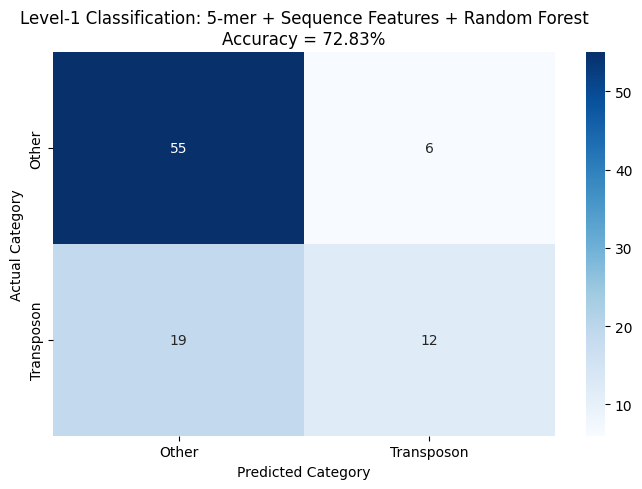

In [ ]:
# Step 65: Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_eng_rf = confusion_matrix(
    y_test_eng,
    y_pred_eng_rf,
    labels=["Other", "Transposon"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_eng_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Other", "Transposon"],
    yticklabels=["Other", "Transposon"]
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title(
    f"Level-1 Classification: 5-mer + Sequence Features + Random Forest\n"
    f"Accuracy = {accuracy_eng_rf * 100:.2f}%"
)

plt.tight_layout()
plt.show()

In [ ]:
# Step 66: Feature Importance

feature_names_eng = X_5mer_engineered.columns

feature_importance_eng = pd.DataFrame({
    "Feature": feature_names_eng,
    "Importance": rf_engineered.feature_importances_
})

feature_importance_eng = feature_importance_eng.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 important features:")
display(feature_importance_eng.head(20))

Top 20 important features:


,Feature,Importance
979,TTCAT,0.004959
1024,Sequence_Length,0.004172
824,TATGA,0.004169
1021,TTTTC,0.003866
206,ATATG,0.003638
563,GATAT,0.003544
655,GGATT,0.003156
835,TCAAT,0.002972
250,ATTGG,0.002813
807,TAGCT,0.002768


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [None, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=8,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_5mer, y_train_5mer)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Macro F1:")
print(random_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}

Best CV Macro F1:
0.6341658927777899


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Best tuned model
best_rf = random_search.best_estimator_

# Predict on untouched test set
y_pred_tuned = best_rf.predict(X_test_5mer)

# Accuracy
accuracy_tuned = accuracy_score(y_test_5mer, y_pred_tuned)

print("Tuned Random Forest Accuracy:",
      round(accuracy_tuned * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test_5mer,
    y_pred_tuned,
    target_names=["Other", "Transposon"]
))

Tuned Random Forest Accuracy: 71.74 %

Classification Report:
              precision    recall  f1-score   support

       Other       0.75      0.87      0.80        61
  Transposon       0.62      0.42      0.50        31

    accuracy                           0.72        92
   macro avg       0.68      0.64      0.65        92
weighted avg       0.70      0.72      0.70        92



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from original 5-mer Random Forest
importance_df = pd.DataFrame({
    "5-mer": kmer5_features,
    "Importance": rf_5mer.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20
print("Top 20 Important 5-mers:")
display(importance_df.head(20))

Top 20 Important 5-mers:


,5-mer,Importance
563,GATAT,0.005562
0,AAAAA,0.004497
655,GGATT,0.004323
824,TATGA,0.004061
250,ATTGG,0.003743
835,TCAAT,0.003607
206,ATATG,0.003601
952,TGTGA,0.003233
994,TTGAG,0.003051
1021,TTTTC,0.002563


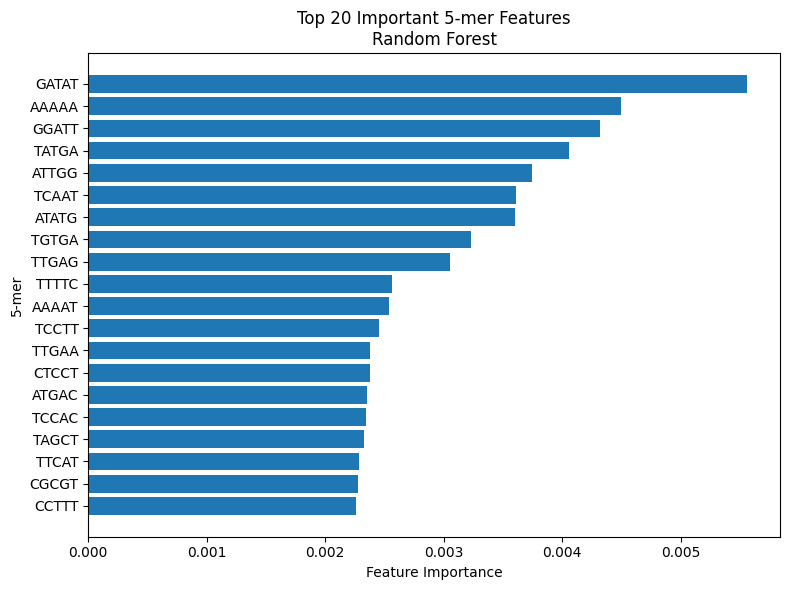

In [ ]:
top20 = importance_df.head(20).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    top20["5-mer"],
    top20["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("5-mer")
plt.title("Top 20 Important 5-mer Features\nRandom Forest")
plt.tight_layout()
plt.show()

In [ ]:
model_comparison = pd.DataFrame({
    "K-mer": ["3-mer", "4-mer", "5-mer", "6-mer"],
    "SVM Accuracy (%)": [52.17, 56.52, 65.22, 67.39],
    "Random Forest Accuracy (%)": [65.22, 70.65, 77.17, 72.83]
})

display(model_comparison)

,K-mer,SVM Accuracy (%),Random Forest Accuracy (%)
0,3-mer,52.17,65.22
1,4-mer,56.52,70.65
2,5-mer,65.22,77.17
3,6-mer,67.39,72.83


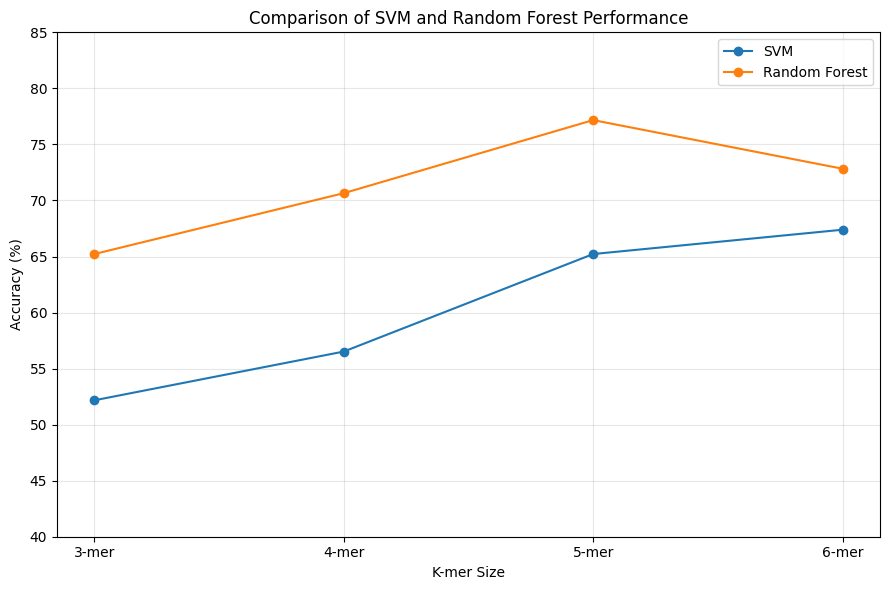

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    model_comparison["K-mer"],
    model_comparison["SVM Accuracy (%)"],
    marker="o",
    label="SVM"
)

plt.plot(
    model_comparison["K-mer"],
    model_comparison["Random Forest Accuracy (%)"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("K-mer Size")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of SVM and Random Forest Performance")
plt.ylim(40, 85)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 100 5-mer features using training data only
selector_100 = SelectKBest(
    score_func=f_classif,
    k=100
)

X_train_100 = selector_100.fit_transform(X_train_5mer, y_train_5mer)
X_test_100 = selector_100.transform(X_test_5mer)

print("Original number of features:", X_train_5mer.shape[1])
print("Selected number of features:", X_train_100.shape[1])
print("Training shape:", X_train_100.shape)
print("Testing shape:", X_test_100.shape)

Original number of features: 1024
Selected number of features: 100
Training shape: (367, 100)
Testing shape: (92, 100)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Random Forest with top 100 selected 5-mer features
rf_100 = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt"
)

rf_100.fit(X_train_100, y_train_5mer)

# Predict on test set
y_pred_100 = rf_100.predict(X_test_100)

# Accuracy
accuracy_100 = accuracy_score(y_test_5mer, y_pred_100)

print("Random Forest + Top 100 5-mers Accuracy:",
      round(accuracy_100 * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test_5mer,
    y_pred_100,
    target_names=["Other", "Transposon"]
))

Random Forest + Top 100 5-mers Accuracy: 71.74 %

Classification Report:
              precision    recall  f1-score   support

       Other       0.74      0.89      0.81        61
  Transposon       0.63      0.39      0.48        31

    accuracy                           0.72        92
   macro avg       0.69      0.64      0.64        92
weighted avg       0.70      0.72      0.70        92



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_5mer = TfidfVectorizer(
    lowercase=False,
    token_pattern=r'(?u)\b[A-Za-z]+\b'
)

tfidf_matrix_5mer = tfidf_5mer.fit_transform(
    df["kmer5_sequence"]
)

tfidf_5mer_features = tfidf_5mer.get_feature_names_out()

print("TF-IDF matrix shape:", tfidf_matrix_5mer.shape)
print("Number of 5-mer features:", len(tfidf_5mer_features))

TF-IDF matrix shape: (459, 1024)
Number of 5-mer features: 1024


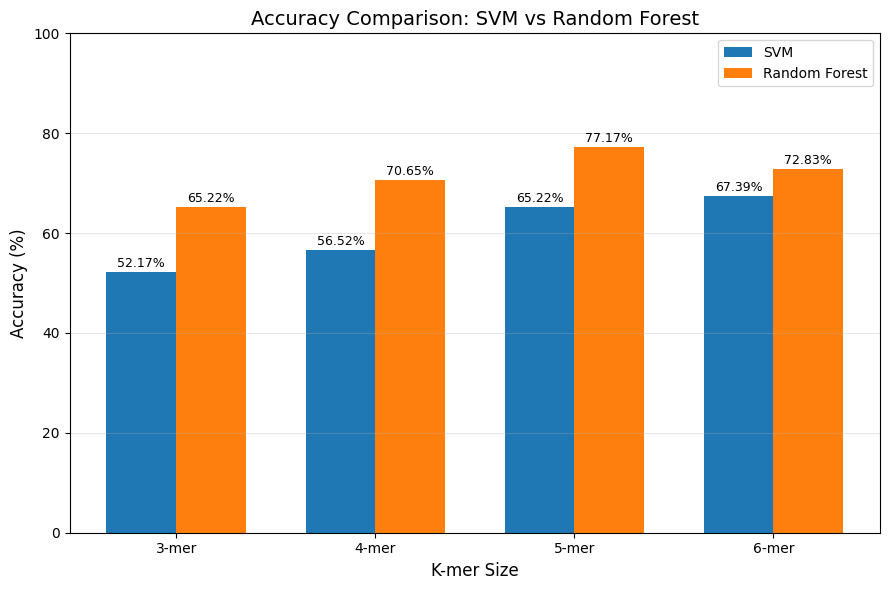

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
kmer_sizes = ["3-mer", "4-mer", "5-mer", "6-mer"]

svm_accuracy = [52.17, 56.52, 65.22, 67.39]
rf_accuracy = [65.22, 70.65, 77.17, 72.83]

x = np.arange(len(kmer_sizes))
width = 0.35

# Create figure
plt.figure(figsize=(9, 6))

plt.bar(
    x - width/2,
    svm_accuracy,
    width,
    label="SVM"
)

plt.bar(
    x + width/2,
    rf_accuracy,
    width,
    label="Random Forest"
)

# Labels
plt.xlabel("K-mer Size", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Accuracy Comparison: SVM vs Random Forest", fontsize=14)

plt.xticks(x, kmer_sizes)
plt.ylim(0, 100)

# Add values on bars
for i, value in enumerate(svm_accuracy):
    plt.text(
        i - width/2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

for i, value in enumerate(rf_accuracy):
    plt.text(
        i + width/2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

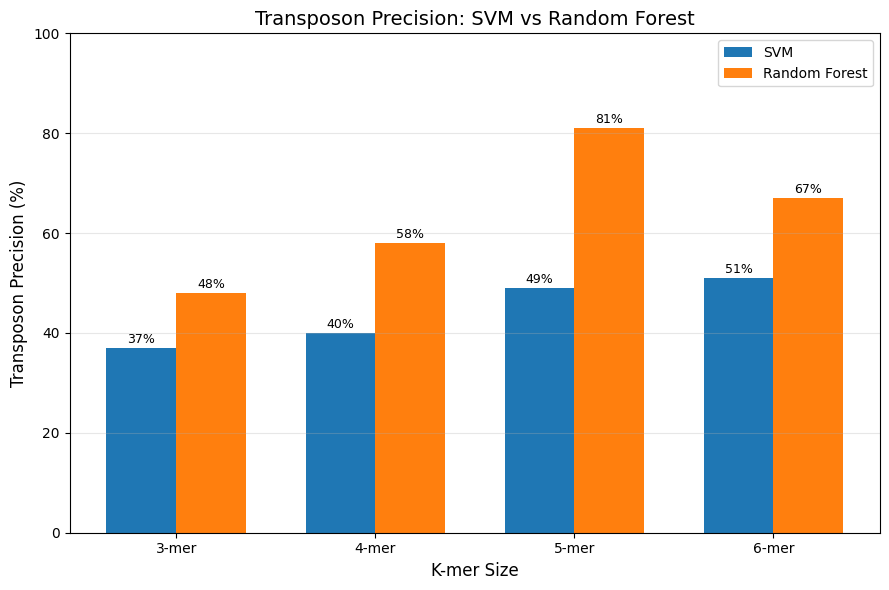

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
kmer_sizes = ["3-mer", "4-mer", "5-mer", "6-mer"]

svm_precision = [37, 40, 49, 51]
rf_precision = [48, 58, 81, 67]

x = np.arange(len(kmer_sizes))
width = 0.35

# Create figure
plt.figure(figsize=(9, 6))

plt.bar(
    x - width/2,
    svm_precision,
    width,
    label="SVM"
)

plt.bar(
    x + width/2,
    rf_precision,
    width,
    label="Random Forest"
)

# Labels
plt.xlabel("K-mer Size", fontsize=12)
plt.ylabel("Transposon Precision (%)", fontsize=12)
plt.title("Transposon Precision: SVM vs Random Forest", fontsize=14)

plt.xticks(x, kmer_sizes)
plt.ylim(0, 100)

# Add values
for i, value in enumerate(svm_precision):
    plt.text(
        i - width/2,
        value + 1,
        f"{value}%",
        ha="center",
        fontsize=9
    )

for i, value in enumerate(rf_precision):
    plt.text(
        i + width/2,
        value + 1,
        f"{value}%",
        ha="center",
        fontsize=9
    )

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()